In [288]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr, spearmanr, linregress

# 한글 폰트 설정 - Windows
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
pd.set_option('display.max_rows', None)

## 가설검정 순서
1. 가설 설정 
    - 대립가설 : 밝히고자 하는 가설
    - 귀무가설 : 대립가설의 반대 / 보통 차이가 없다 같은 내용을 담음. 
2. 검정 방법 선택
3. 유의수준 결정
4. 검정통계량과 p-value
5. 결론/결과해석
    - p-value < 유의 수준 : 귀무가설 기각 / 대립가설 채택
    - p-value >= 유의 수준 : 귀무가설 채택/ 대립가설 기각

# 1. 가설: 공시지가 상승률이 높은 지역일수록 프랜차이즈 침투율이 높은것이다.

In [289]:
MAIN_PATH = Path("../data/ML용_행정동_분기_마스터.csv")
main = pd.read_csv(MAIN_PATH, encoding="utf-8-sig") 

# 기존 통계 코드와 새 ML용 마스터의 컬럼명 호환 처리
if "전입_소득수준_가중평균_분기" not in main.columns and "전입_소득수준_가중평균" in main.columns:
    main["전입_소득수준_가중평균_분기"] = main["전입_소득수준_가중평균"]
legal = pd.read_csv("../data/법정동_연도_마스터.csv", encoding="utf-8-sig")
print(main.shape) 
print(legal.shape) 
main.head()

(600, 47)
(129, 20)


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,2070,355,0.171498,3077.294686
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624,1906,339,0.177859,3122.245540
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624,1790,301,0.168156,3088.826816
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624,1768,310,0.175339,3141.968326
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,1677,292,0.174120,3115.086464


In [290]:
print("main 컬럼")
print(main.columns.tolist())

print("\nlegal 컬럼")
print(legal.columns.tolist())

main 컬럼
['base_quarter', 'year', 'quarter', 'adm_dong_cd', 'adm_dong_nm', 'gu', 'floating_pop', 'purpose_0_ratio', 'purpose_1_ratio', 'purpose_2_ratio', 'purpose_3_ratio', 'purpose_4_ratio', 'purpose_5_ratio', 'purpose_6_ratio', 'external_inflow', 'stay_time_weighted', 'stay_time_cnt', 'transport_total_cnt', 'transport_0_ratio', 'transport_1_ratio', 'transport_2_ratio', 'transport_3_ratio', 'transport_4_ratio', 'transport_5_ratio', 'transport_6_ratio', 'transport_7_ratio', 'sales_amt', 'sales_cnt', 'avg_ticket', 'new_corp_cnt', 'store_mer_cnt', 'franchise_cnt', 'open_cnt', 'close_cnt', 'open_rate', 'close_rate', 'franchise_ratio', 'industry_diversity_H', 'survival_rate_1y', 'bus_board_cnt', 'bus_alight_cnt', '전입_소득수준_가중평균', '전출_소득수준_가중평균', '전입_총인원', '전입_고소득층_인원', '전입_고소득층_비율', '전입_소득수준_가중평균_분기']

legal 컬럼
['legal_dong_nm', 'legal_dong_full_nm', 'gu', 'year', 'land_price_median', 'land_price_growth', 'land_price_growth_yoy', 'land_parcel_cnt', 'land_parcel_count_ok', 'land_price_2023_me

In [291]:
# 가설검정 반복하기위한 함수 코드
def one_sided_p(r, p_two, alternative):
    """상관계수 방향에 맞춘 단측검정 p-value 계산"""
    if alternative == "greater":
        if r > 0:
            return p_two / 2
        if r < 0:
            return 1 - (p_two / 2)
        return 0.5
    if alternative == "less":
        if r < 0:
            return p_two / 2
        if r > 0:
            return 1 - (p_two / 2)
        return 0.5
    return p_two


def corr_test(df, x_col, y_col, hypothesis, alternative="two-sided", min_n=10):
    """
    Pearson / Spearman 상관검정 함수
    alternative:
        "greater" = 양의 관계 단측검정
        "less" = 음의 관계 단측검정
        "two-sided" = 양측검정
    """
    temp = df[[x_col, y_col]].dropna()
    n = len(temp)

    if n < min_n:
        return {
            "가설": hypothesis,
            "X변수": x_col,
            "Y변수": y_col,
            "표본수": n,
            "Pearson_r": None,
            "Pearson_p": None,
            "Spearman_rho": None,
            "Spearman_p": None,
            "판정": "표본 부족"
        }

    x = temp[x_col]
    y = temp[y_col]

    pearson_r, pearson_p_two = pearsonr(x, y)
    spearman_rho, spearman_p_two = spearmanr(x, y)

    if alternative in ["greater", "less"]:
        pearson_p = one_sided_p(pearson_r, pearson_p_two, alternative)
        spearman_p = one_sided_p(spearman_rho, spearman_p_two, alternative)
    else:
        pearson_p = pearson_p_two
        spearman_p = spearman_p_two

    if spearman_p < 0.05:
        decision = "유의함"
    elif spearman_p < 0.1:
        decision = "약한 경향"
    else:
        decision = "유의하지 않음"

    return {
        "가설": hypothesis,
        "X변수": x_col,
        "Y변수": y_col,
        "표본수": n,
        "Pearson_r": round(pearson_r, 4),
        "Pearson_p": round(pearson_p, 4),
        "Spearman_rho": round(spearman_rho, 4),
        "Spearman_p": round(spearman_p, 4),
        "판정": decision
    }

2. 가설 설정
- 귀무가설: 공시지가 상승률과 프랜차이즈 침투율은 상관관계가 없다.
- 대립가설: 공시지가 상승률과 프랜차이즈 침투율이 높으면 상관관계가 있다.

일단 행정동이랑 법정동 데이터가 main은 분기 단위이고, legal는 연도 단위이니 main을 연도 단위로 바꿔야됨

In [292]:
main["year"] = main["base_quarter"].str[:4].astype(int)

main_year = main.groupby(
    ["gu", "adm_dong_nm", "year"],
    as_index=False
).agg(
    franchise_ratio=("franchise_ratio", "mean"),
    franchise_cnt=("franchise_cnt", "mean")
)

display(main_year.head())
print(main_year.shape)

,gu,adm_dong_nm,year,franchise_ratio,franchise_cnt
0,분당구,구미1동,2023,4.928932,308.50
1,분당구,구미1동,2024,5.195820,330.00
2,분당구,구미1동,2025,4.811551,321.25
3,분당구,구미동,2023,7.499455,611.25
4,분당구,구미동,2024,7.915777,658.50


(150, 5)


In [293]:
# 행정동명 1동 2동을 법정동명에 맞추기
def make_legal_key(x):
    x = str(x)
    return re.sub(r"(.+)\d+동$", r"\1동", x)

main_year["legal_key"] = main_year["adm_dong_nm"].apply(make_legal_key)

display(main_year[["adm_dong_nm", "legal_key"]].drop_duplicates().head(30))

,adm_dong_nm,legal_key
0,구미1동,구미동
3,구미동,구미동
6,금곡동,금곡동
9,백현동,백현동
12,분당동,분당동
15,삼평동,삼평동
18,서현1동,서현동
21,서현2동,서현동
24,수내1동,수내동
27,수내2동,수내동


행정동데이터를 법정동명으로 매핑 완료 그래서 공시지가 데이터와 병합

In [294]:
h1_master = main_year.merge(
    legal[["gu", "legal_dong_nm", "year", "land_price_growth"]],
    left_on=["gu", "legal_key", "year"],
    right_on=["gu", "legal_dong_nm", "year"],
    how="inner"
)

print("병합 후 행 수:", len(h1_master))
display(h1_master.head())

병합 후 행 수: 147


,gu,adm_dong_nm,year,franchise_ratio,franchise_cnt,legal_key,legal_dong_nm,land_price_growth
0,분당구,구미1동,2023,4.928932,308.50,구미동,구미동,NaN
1,분당구,구미1동,2024,5.195820,330.00,구미동,구미동,2.669029
2,분당구,구미1동,2025,4.811551,321.25,구미동,구미동,3.018522
3,분당구,구미동,2023,7.499455,611.25,구미동,구미동,NaN
4,분당구,구미동,2024,7.915777,658.50,구미동,구미동,2.669029


In [295]:
# 가설검정에 쓸 수있는 분석 가능 행수 확인
h1_data = h1_master[[
    "gu",
    "adm_dong_nm",
    "legal_key",
    "legal_dong_nm",
    "year",
    "land_price_growth",
    "franchise_ratio"
]].dropna()

print("H1 분석 가능 행 수:", len(h1_data))
display(h1_data.head())

H1 분석 가능 행 수: 98


,gu,adm_dong_nm,legal_key,legal_dong_nm,year,land_price_growth,franchise_ratio
1,분당구,구미1동,구미동,구미동,2024,2.669029,5.195820
2,분당구,구미1동,구미동,구미동,2025,3.018522,4.811551
4,분당구,구미동,구미동,구미동,2024,2.669029,7.915777
5,분당구,구미동,구미동,구미동,2025,3.018522,7.579956
7,분당구,금곡동,금곡동,금곡동,2024,4.493319,5.580629


In [296]:
# 이제 상관관계 검정 실행
h1_result = corr_test(
    h1_data,
    x_col="land_price_growth",
    y_col="franchise_ratio",
    hypothesis="H1 공시지가 상승률이 높은 지역일수록 프랜차이즈 침투율이 높을 것이다",
    alternative="greater"
)

h1_result_df = pd.DataFrame([h1_result])
display(h1_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H1 공시지가 상승률이 높은 지역일수록 프랜차이즈 침투율이 높을 것이다,land_price_growth,franchise_ratio,98,0.3025,0.0012,0.256,0.0055,유의함


r은 직선관계 rho는 순위 관계

| 구분     | Pearson r                  | Spearman rho                |
| ------ | -------------------------- | --------------------------- |
| 보는 것   | 실제 값의 직선 관계                | 순위 관계                       |
| 관계 형태  | 선형 관계                      | 단조 관계                       |
| 이상치 영향 | 상대적으로 큼                    | 상대적으로 작음                    |
| 예시 질문  | 상승률이 커질수록 침투율이 직선적으로 증가하나? | 상승률 순위가 높은 지역이 침투율 순위도 높은가? |
| 네 결과   | r = 0.3025                 | rho = 0.2560                |


상관관계에 비해 p값은 작은데 이유는 상관관계가 없다고 가정했을 떄 지금같은 결과가 우연히 나올 가능성이 낮다는 뜻이다.
그래서 상관관계를 봤을때 0.30, 0.25로 귀무가설을 기각하고 두 변수사이에 통계적으로 약한 상관관계가 있다고 볼 수 있다.

# 2. 가설: 공시지가 상승률이 높은 지역일수록 상업용 부동산 거래량이 많을 것이다.

1. 가설 설정
- 귀무가설: 공시지가 상승률과 상업용 부동산 거래량은 상관관계가 없다.
- 대립가설: 공시지가 상승률이 높을수록 상업용 부동산 거래량도 많아지는 상관관계가 있다.

In [297]:
legal_q = pd.read_csv("../data/법정동_분기_마스터.csv", encoding="utf-8-sig")

print(legal_q.shape)
print(legal_q.columns.tolist())
display(legal_q.head())

(516, 17)
['legal_dong_nm', 'legal_dong_full_nm', 'gu', 'base_quarter', 'year', 'quarter', 'land_price_median', 'land_price_growth', 'land_price_growth_yoy', 'land_parcel_cnt', 'land_parcel_count_ok', 'land_growth_23_25_median', 'land_growth_cagr_23_25_median', 'land_growth_23_25_mean', 'transaction_cnt', 'transaction_amt_sum', 'transaction_amt_mean']


,legal_dong_nm,legal_dong_full_nm,gu,base_quarter,year,quarter,land_price_median,land_price_growth,land_price_growth_yoy,land_parcel_cnt,land_parcel_count_ok,land_growth_23_25_median,land_growth_cagr_23_25_median,land_growth_23_25_mean,transaction_cnt,transaction_amt_sum,transaction_amt_mean
0,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q1,2023,1,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
1,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q2,2023,2,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
2,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q3,2023,3,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
3,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q4,2023,4,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
4,갈현동,경기도 성남시 중원구 갈현동,중원구,2024Q1,2024,1,1775000.0,0.860585,0.860585,19,False,4.532415,2.241095,5.474931,0,0.0,NaN


공시지가 상승률은 연도 단위 변수이므로, 상업용 부동산 거래량도 법정동-연도 단위로 맞춰 분석한다.
`법정동_연도_마스터.csv`에 연도별 거래량 합계를 추가했기 때문에, H2는 분기 마스터가 아니라 연도 마스터 기준으로 검정한다.


In [ ]:
# H2: 공시지가 상승률과 거래량 모두 법정동-연도 단위로 분석
h2_data = legal[[
    "gu",
    "legal_dong_nm",
    "year",
    "land_price_growth",
    "transaction_cnt"
]].replace([np.inf, -np.inf], np.nan).dropna()

print("H2 분석 가능 행 수(법정동-연도):", len(h2_data))
display(h2_data.head())


In [ ]:
h2_result = corr_test(
    h2_data,
    x_col="land_price_growth",
    y_col="transaction_cnt",
    hypothesis="H2 공시지가 상승률이 높은 지역일수록 상업용 부동산 거래량이 많을 것이다",
    alternative="greater"
)

pd.DataFrame([h2_result])

거래량이 0인 법정동-연도를 포함한 연도 단위 상관계수 표


H2를 연도 단위로 다시 맞춘 결과, Pearson 기준으로는 약한 양의 선형관계가 나타났지만 Spearman 순위상관은 유의수준 0.05에서 유의하지 않았다.

- 표본수: 86개 법정동-연도
- Pearson r = 0.1880, 단측 p = 0.0415
- Spearman rho = 0.1345, 단측 p = 0.1085

따라서 “공시지가 상승률이 높은 지역일수록 상업용 부동산 거래량이 많다”는 H2는 강하게 지지된다고 보기 어렵다. 거래량이 특정 법정동에 몰리고 0값도 존재하기 때문에, 최종 해석은 Spearman 결과를 중심으로 `유의하지 않음`으로 정리한다.


In [ ]:
h2_data_positive = h2_data[h2_data["transaction_cnt"] > 0].copy()

print("거래 발생 행 수:", len(h2_data_positive))
display(h2_data_positive.head())

In [ ]:
h2_result_positive = corr_test(
    h2_data_positive,
    x_col="land_price_growth",
    y_col="transaction_cnt",
    hypothesis="H2 거래 발생 지역에서 공시지가 상승률이 높을수록 상업용 부동산 거래량이 많을 것이다",
    alternative="greater"
)

pd.DataFrame([h2_result_positive])


In [ ]:
x = h2_data_positive["land_price_growth"]
y = h2_data_positive["transaction_cnt"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

# 추세선
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H2: Land Price Growth vs Transaction Count")
plt.xlabel("공시지가 상승률")
plt.ylabel("상업용 부동산 거래량")
plt.grid(True, alpha=0.3)
plt.show()


거래가 실제 발생한 법정동-연도만 대상으로 한 추가 상관계수 표


거래량이 0인 법정동-연도를 제외해도 Spearman 순위상관은 유의수준 0.05에서 유의하지 않았다.

- 표본수: 74개 법정동-연도
- Pearson r = 0.2007, 단측 p = 0.0432
- Spearman rho = 0.1377, 단측 p = 0.1211

즉 거래가 발생한 지역만 보아도 공시지가 상승률과 거래량 사이의 순위 관계는 안정적으로 확인되지 않는다. Pearson 기준의 약한 양의 관계는 참고할 수 있지만, H2 채택 근거로 보기는 어렵다.


기존 분기 단위 검정에서는 연도별 공시지가 상승률이 Q1~Q4에 반복되어 표본수가 344개처럼 계산되었다. 이때는 Spearman p-value가 0.0186으로 유의하게 보였지만, 이는 같은 연도 상승률을 4번 반복해서 사용한 영향이 있을 수 있다.

수정 후에는 법정동-연도 단위 86개 관측치로 검정했고, Spearman p-value가 0.1085로 바뀌었다. 따라서 기존의 “유의한 양의 관계” 해석은 사용하지 않고, H2는 `유의하지 않음`으로 정리한다.


H2 최종 결론: 공시지가 상승률과 상업용 부동산 거래량 사이에는 약한 양의 선형관계 가능성은 있으나, 순위상관 기준에서는 통계적으로 유의하지 않다. 따라서 H2는 지지되지 않는다.


1. 가설설정
- 귀무가설: 지하철 이용량과 개업률, 폐업률, 프랜차이즈 침투율은 상관관계가 없다.
- 대립가설: 지하철 이용량과 개업률, 폐업률, 프랜차이즈 침투율은 상관관계가 있다.

지하철 이용량이 들어가니 지하철 마스터 테이블 불러오기


In [303]:
subway = pd.read_csv("../data/지하철역_분기_승하차_행정동추가.csv", encoding="utf-8-sig")

print(subway.shape)
print(subway.columns.tolist())
display(subway.head())

(284, 6)
['base_quarter', 'subway_line', 'station_nm', '행정동', 'subway_board_cnt', 'subway_alight_cnt']


,base_quarter,subway_line,station_nm,행정동,subway_board_cnt,subway_alight_cnt
0,2023Q1,8호선,남위례,복정동,533088,551249
1,2023Q1,8호선,남한산성입구(성남법원.검찰청),단대동,1161235,1053034
2,2023Q1,8호선,단대오거리,단대동,1030034,991383
3,2023Q1,8호선,모란,성남동,427255,345384
4,2023Q1,8호선,복정,복정동,777372,657178


In [304]:
# 행정동 및 분기 단위로 지하철 이용량 집계
subway["subway_total_usage"] = subway["subway_board_cnt"] + subway["subway_alight_cnt"]
subway_agg = subway.groupby(
    ["행정동", "base_quarter"],
    as_index=False
).agg(
    subway_board_cnt=("subway_board_cnt", "sum"),
    subway_alight_cnt=("subway_alight_cnt", "sum"),
    subway_total_usage=("subway_total_usage", "sum"),
    subway_station_cnt=("station_nm", "nunique")
)

subway_agg = subway_agg.rename(columns={"행정동": "adm_dong_nm"})

display(subway_agg.head())
print(subway_agg.shape)

,adm_dong_nm,base_quarter,subway_board_cnt,subway_alight_cnt,subway_total_usage,subway_station_cnt
0,구미1동,2023Q1,2251742,2161611,4413353,2
1,구미1동,2023Q2,2303901,2220137,4524038,2
2,구미1동,2023Q3,2188131,2110266,4298397,2
3,구미1동,2023Q4,2305612,2222072,4527684,2
4,구미1동,2024Q1,2293668,2204340,4498008,2


(192, 6)


행정동 및 분기 단위로 cnt값이 집계 된것을 볼 수 있다.

In [305]:
# 이값을 main 컬럼에 있는 개폐업률, 프랜차이즈 침투율과 합치기
# ML용 마스터에는 지하철 컬럼이 이미 있으므로, 재집계한 subway_agg와 컬럼명이 겹치지 않게 제거 후 병합한다.
subway_overlap_cols = [
    "subway_board_cnt",
    "subway_alight_cnt",
    "subway_total_usage",
    "subway_station_cnt",
]
main_subway_base = main.drop(columns=subway_overlap_cols, errors="ignore")

main_subway = main_subway_base.merge(
    subway_agg,
    on=["adm_dong_nm", "base_quarter"],
    how="left"
)

print(main_subway.shape)
display(main_subway.head())

(600, 51)


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기,subway_board_cnt,subway_alight_cnt,subway_total_usage,subway_station_cnt
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3188.370885,3252.77624,2070,355,0.171498,3077.294686,443491.0,463235.0,906726.0,1.0
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3188.370885,3252.77624,1906,339,0.177859,3122.245540,459727.0,482111.0,941838.0,1.0
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3188.370885,3252.77624,1790,301,0.168156,3088.826816,443162.0,466437.0,909599.0,1.0
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3188.370885,3252.77624,1768,310,0.175339,3141.968326,455789.0,478357.0,934146.0,1.0
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3188.370885,3252.77624,1677,292,0.174120,3115.086464,456298.0,472687.0,928985.0,1.0


지하철역이 없는 동은 nan값 처리됨
지하철역이 없는 동은 이용량도 없는 것이니 nan값을 0으로 처리

In [306]:
subway_cols = [
    "subway_board_cnt",
    "subway_alight_cnt",
    "subway_total_usage",
    "subway_station_cnt"
]

main_subway[subway_cols] = main_subway[subway_cols].fillna(0)

### 지하철 이용량 기준 역세권 판단
- `is_subway_area`: 행정동 평균 지하철 이용량이 0보다 크면 1, 아니면 0
- `is_core_subway_area`: 지하철 이용량이 있는 행정동 중 평균 이용량 상위 25%이면 1
- `subway_area_level`: 비역세권 / 일반역세권 / 중간역세권 / 핵심역세권

In [307]:
subway_dong_usage = (
    main_subway
    .groupby(["gu", "adm_dong_nm"], as_index=False)
    .agg(
        subway_usage_mean=("subway_total_usage", "mean"),
        subway_usage_max=("subway_total_usage", "max"),
        subway_station_cnt_mean=("subway_station_cnt", "mean")
    )
)

nonzero_subway_usage = subway_dong_usage.loc[
    subway_dong_usage["subway_usage_mean"] > 0,
    "subway_usage_mean"
]
subway_usage_q50 = nonzero_subway_usage.quantile(0.50)
subway_usage_q75 = nonzero_subway_usage.quantile(0.75)

subway_dong_usage["is_subway_area"] = (
    subway_dong_usage["subway_usage_mean"] > 0
).astype(int)
subway_dong_usage["is_core_subway_area"] = (
    subway_dong_usage["subway_usage_mean"] >= subway_usage_q75
).astype(int)

subway_dong_usage["subway_area_level"] = np.select(
    [
        subway_dong_usage["subway_usage_mean"] == 0,
        subway_dong_usage["subway_usage_mean"] < subway_usage_q50,
        subway_dong_usage["subway_usage_mean"] < subway_usage_q75,
        subway_dong_usage["subway_usage_mean"] >= subway_usage_q75,
    ],
    ["비역세권", "일반역세권", "중간역세권", "핵심역세권"],
    default="비역세권"
)

subway_area_cols = [
    "subway_usage_mean",
    "subway_usage_max",
    "subway_station_cnt_mean",
    "is_subway_area",
    "is_core_subway_area",
    "subway_area_level",
]
main_subway = main_subway.drop(
    columns=[col for col in subway_area_cols if col in main_subway.columns],
    errors="ignore"
)

main_subway = main_subway.merge(
    subway_dong_usage[
        [
            "gu",
            "adm_dong_nm",
            "subway_usage_mean",
            "subway_usage_max",
            "subway_station_cnt_mean",
            "is_subway_area",
            "is_core_subway_area",
            "subway_area_level",
        ]
    ],
    on=["gu", "adm_dong_nm"],
    how="left"
)

print("역세권 판단 기준 - 이용량 있는 행정동 q50:", subway_usage_q50)
print("역세권 판단 기준 - 이용량 있는 행정동 q75:", subway_usage_q75)
display(
    subway_dong_usage
    .sort_values("subway_usage_mean", ascending=False)
    .head(20)
)

역세권 판단 기준 - 이용량 있는 행정동 q50: 2560246.041666667
역세권 판단 기준 - 이용량 있는 행정동 q75: 4479655.958333333


,gu,adm_dong_nm,subway_usage_mean,subway_usage_max,subway_station_cnt_mean,is_subway_area,is_core_subway_area,subway_area_level
3,분당구,백현동,6.581029e+06,6927314.0,1.666667,1,1,핵심역세권
11,분당구,야탑1동,4.538632e+06,4715202.0,1.000000,1,1,핵심역세권
17,분당구,정자1동,4.514266e+06,4667485.0,1.000000,1,1,핵심역세권
45,중원구,성남동,4.494104e+06,4675558.0,1.000000,1,1,핵심역세권
0,분당구,구미1동,4.474840e+06,4633163.0,2.000000,1,0,중간역세권
23,수정구,단대동,4.309839e+06,4578185.0,2.000000,1,0,중간역세권
6,분당구,서현1동,4.227264e+06,4336352.0,1.000000,1,0,중간역세권
24,수정구,복정동,2.777641e+06,3023390.0,2.000000,1,0,중간역세권
2,분당구,금곡동,2.342851e+06,2466448.0,1.000000,1,0,일반역세권
8,분당구,수내1동,2.333586e+06,2431946.0,1.000000,1,0,일반역세권


In [308]:
main_subway.head()

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,subway_board_cnt,subway_alight_cnt,subway_total_usage,subway_station_cnt,subway_usage_mean,subway_usage_max,subway_station_cnt_mean,is_subway_area,is_core_subway_area,subway_area_level
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,443491.0,463235.0,906726.0,1.0,935394.25,963946.0,1.0,1,0,일반역세권
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,459727.0,482111.0,941838.0,1.0,935394.25,963946.0,1.0,1,0,일반역세권
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,443162.0,466437.0,909599.0,1.0,935394.25,963946.0,1.0,1,0,일반역세권
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,455789.0,478357.0,934146.0,1.0,935394.25,963946.0,1.0,1,0,일반역세권
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,456298.0,472687.0,928985.0,1.0,935394.25,963946.0,1.0,1,0,일반역세권


In [309]:
h3_tests = [corr_test(
        main_subway,
        x_col="subway_total_usage",
        y_col="open_rate",
        hypothesis="H3-1 지하철 이용량은 개업률과 관련이 있다",
        alternative="two-sided"
    ),
    corr_test(
        main_subway,
        x_col="subway_total_usage",
        y_col="close_rate",
        hypothesis="H3-2 지하철 이용량은 폐업률과 관련이 있다",
        alternative="two-sided"
    ),
    corr_test(
        main_subway,
        x_col="subway_total_usage",
        y_col="franchise_ratio",
        hypothesis="H3-3 지하철 이용량은 프랜차이즈 침투율과 관련이 있다",
        alternative="two-sided"
    )
]

h3_result_df = pd.DataFrame(h3_tests)
display(h3_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H3-1 지하철 이용량은 개업률과 관련이 있다,subway_total_usage,open_rate,600,0.0997,0.0146,0.0997,0.0145,유의함
1,H3-2 지하철 이용량은 폐업률과 관련이 있다,subway_total_usage,close_rate,600,-0.0347,0.3961,0.0104,0.8002,유의하지 않음
2,H3-3 지하철 이용량은 프랜차이즈 침투율과 관련이 있다,subway_total_usage,franchise_ratio,600,0.4281,0.0000,0.1465,0.0003,유의함


첫 번째로, 지하철 이용량과 개업률은 통계적으로 유의한 관계가 확인되었다. 다만 상관계수가 약 0.10 수준으로 매우 낮기 때문에, 실질적으로는 매우 약한 양의 상관관계로 해석하는 것이 적절하다. 즉, 지하철 이용량이 많은 지역에서 개업률이 약간 높게 나타나는 경향은 있으나, 강한 관계라고 보기는 어렵다.

두 번째로, 지하철 이용량과 폐업률은 유의한 관계가 확인되지 않았다. 따라서 현재 데이터만으로는 지하철 이용량이 많다고 해서 폐업률이 높거나 낮다고 판단하기 어렵다.현재 데이터만으로는 관계가 있다고 볼 충분한 증거가 없다

세 번째로, 지하철 이용량과 프랜차이즈 침투율은 통계적으로 유의한 관계가 확인되었다. Pearson 상관계수는 0.4281로 나타나, 선형관계 기준에서는 지하철 이용량이 많을수록 프랜차이즈 침투율도 증가하는 경향이 있다. 그러나 Spearman 상관계수는 0.1465로 약하게 나타났기 때문에, 지하철 이용량 순위가 높은 동이 항상 프랜차이즈 침투율 순위도 높은 것은 아니라고 볼 수 있다.

따라서 H3는 전체적으로 부분적으로 지지된다고 정리할 수 있다. 지하철 이용량은 개업률과 프랜차이즈 침투율과는 관련성이 일부 확인되었지만, 폐업률과는 유의한 관계가 확인되지 않았다.

p-value 작음
→ 우연히 나왔을 가능성이 낮음
→ 귀무가설 기각
→ 관계가 있다고 볼 근거 있음

p-value 큼
→ 우연히 나왔을 가능성이 높음
→ 귀무가설 기각 못함
→ 관계가 있다고 볼 근거 부족

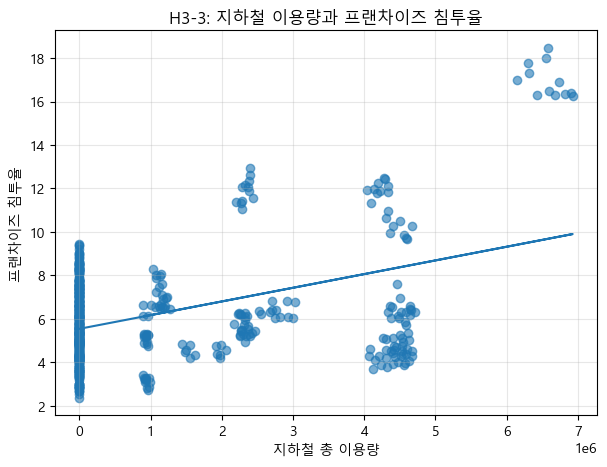

In [310]:
# H3-3 그래프용 데이터 만들기
h3_3_data = main_subway[
    (main_subway["subway_total_usage"].notna()) &
    (main_subway["franchise_ratio"].notna())
].copy()

# 혹시 0 이하 값 제외하고 싶으면 아래 조건 사용
# h3_3_data = main_subway[
#     (main_subway["subway_total_usage"] > 0) &
#     (main_subway["franchise_ratio"] >= 0)
# ].dropna(subset=["subway_total_usage", "franchise_ratio"]).copy()

x = h3_3_data["subway_total_usage"]
y = h3_3_data["franchise_ratio"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

# 추세선
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.title("H3-3: 지하철 이용량과 프랜차이즈 침투율")
plt.xlabel("지하철 총 이용량")
plt.ylabel("프랜차이즈 침투율")
plt.grid(True, alpha=0.3)
plt.show()

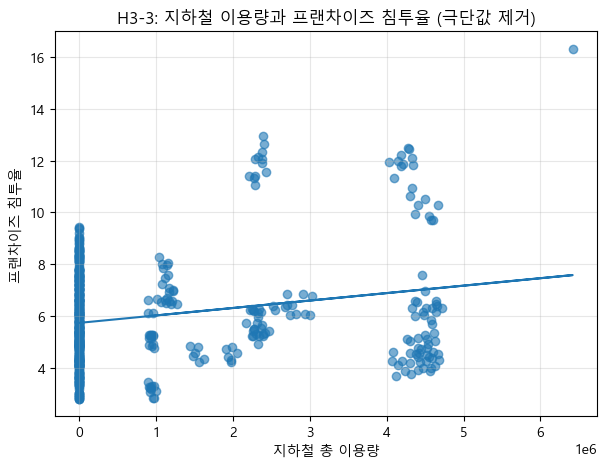

표본 수: 583
Pearson r: 0.21959895045066485
Pearson p-value: 8.487677159466973e-08
Spearman rho: 0.08160930246686574
Spearman p-value: 0.04889044771847517


In [311]:
# H3-3 데이터
h3_3_data = main_subway.dropna(
    subset=["subway_total_usage", "franchise_ratio"]
).copy()

# 상하위 1% 기준값
x_low = h3_3_data["subway_total_usage"].quantile(0.01)
x_high = h3_3_data["subway_total_usage"].quantile(0.99)

y_low = h3_3_data["franchise_ratio"].quantile(0.01)
y_high = h3_3_data["franchise_ratio"].quantile(0.99)

# 극단값 제거 데이터
h3_3_no_outlier = h3_3_data[
    (h3_3_data["subway_total_usage"] >= x_low) &
    (h3_3_data["subway_total_usage"] <= x_high) &
    (h3_3_data["franchise_ratio"] >= y_low) &
    (h3_3_data["franchise_ratio"] <= y_high)
].copy()

x = h3_3_no_outlier["subway_total_usage"]
y = h3_3_no_outlier["franchise_ratio"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.title("H3-3: 지하철 이용량과 프랜차이즈 침투율 (극단값 제거)")
plt.xlabel("지하철 총 이용량")
plt.ylabel("프랜차이즈 침투율")
plt.grid(True, alpha=0.3)
plt.show()

# 상관분석 다시 확인
pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

print("표본 수:", len(h3_3_no_outlier))
print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)
print("Spearman rho:", spearman_rho)
print("Spearman p-value:", spearman_p)

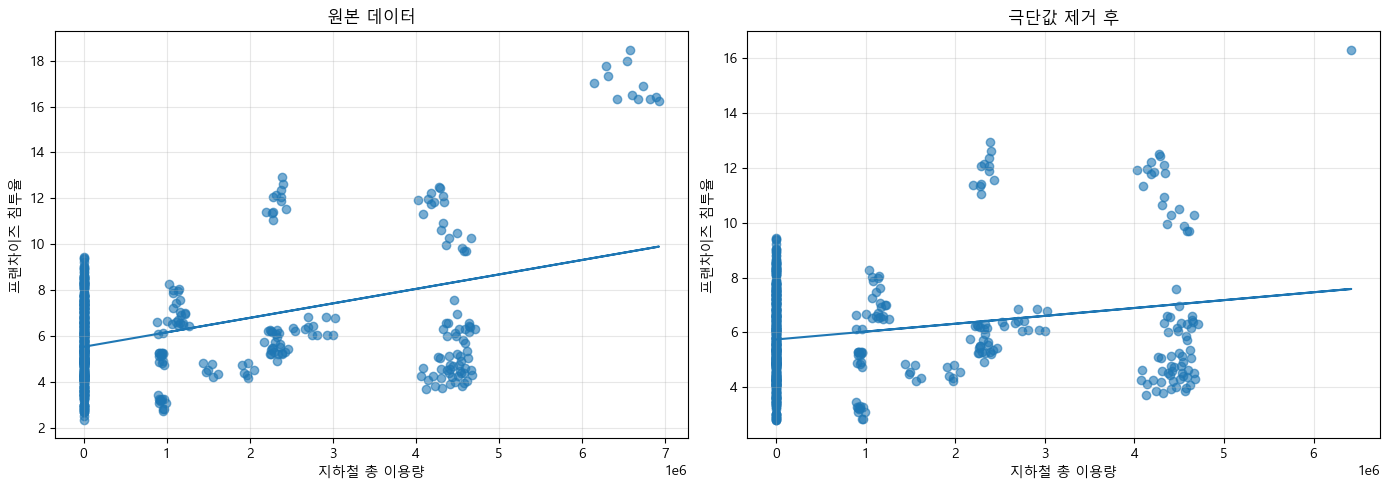

In [312]:
# 원본 데이터
h3_3_data = main_subway.dropna(
    subset=["subway_total_usage", "franchise_ratio"]
).copy()

# 극단값 제거
x_low = h3_3_data["subway_total_usage"].quantile(0.01)
x_high = h3_3_data["subway_total_usage"].quantile(0.99)

y_low = h3_3_data["franchise_ratio"].quantile(0.01)
y_high = h3_3_data["franchise_ratio"].quantile(0.99)

h3_3_no_outlier = h3_3_data[
    (h3_3_data["subway_total_usage"] >= x_low) &
    (h3_3_data["subway_total_usage"] <= x_high) &
    (h3_3_data["franchise_ratio"] >= y_low) &
    (h3_3_data["franchise_ratio"] <= y_high)
].copy()

plt.figure(figsize=(14, 5))

# 1. 원본 그래프
plt.subplot(1, 2, 1)

x1 = h3_3_data["subway_total_usage"]
y1 = h3_3_data["franchise_ratio"]

plt.scatter(x1, y1, alpha=0.6)

m1, b1 = np.polyfit(x1, y1, 1)
plt.plot(x1, m1 * x1 + b1)

plt.title("원본 데이터")
plt.xlabel("지하철 총 이용량")
plt.ylabel("프랜차이즈 침투율")
plt.grid(True, alpha=0.3)

# 2. 극단값 제거 그래프
plt.subplot(1, 2, 2)

x2 = h3_3_no_outlier["subway_total_usage"]
y2 = h3_3_no_outlier["franchise_ratio"]

plt.scatter(x2, y2, alpha=0.6)

m2, b2 = np.polyfit(x2, y2, 1)
plt.plot(x2, m2 * x2 + b2)

plt.title("극단값 제거 후")
plt.xlabel("지하철 총 이용량")
plt.ylabel("프랜차이즈 침투율")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [313]:
print("x 99% 기준:", x_high)
print("y 99% 기준:", y_high)

print("극단값 제거 후 x 최대값:", h3_3_no_outlier["subway_total_usage"].max())
print("극단값 제거 후 y 최대값:", h3_3_no_outlier["franchise_ratio"].max())

x 99% 기준: 6582305.12
y 99% 기준: 16.505518752760462
극단값 제거 후 x 최대값: 6420873.0
극단값 제거 후 y 최대값: 16.31361577404743


| 검정 방법         | 변수 타입             | 보는 것          | 프로젝트 예시                   |
| ------------- | ----------------- | ------------- | ------------------------- |
| Pearson       | 수치형 × 수치형         | 선형 상관관계       | 공시지가 상승률 ↔ 프랜차이즈 침투율      |
| Spearman      | 수치형/순위형 × 수치형/순위형 | 순위 상관관계       | 지하철 이용량 순위 ↔ 프랜차이즈 침투율 순위 |
| Kendall’s tau | 순위형/수치형 × 순위형/수치형 | 순위쌍 일치 관계     | 표본 작을 때 순위 관계 보조 확인       |
| t-test        | 2집단 범주형 × 수치형     | 두 집단 평균 차이    | 역세권/비역세권의 개업률 차이          |
| ANOVA         | 3집단 이상 범주형 × 수치형  | 여러 집단 평균 차이   | 위험등급 고/중/저별 폐업률 차이        |
| 카이제곱          | 범주형 × 범주형         | 두 범주형 변수의 관련성 | 역세권 여부 × 고위험지역 여부         |


# 4. 가설: 외부유입 비율이 높은 행정동일수록 부동산 거래량이 많을 것이다.

1. 가설설정
- 귀무가설: 외부유입 비율과 상업용 부동산 거래량은 상관관계가 없다.
- 대립가설: 외부유입 비율이 높을수록 상업용 부동산 거래량이 많아지는 상관관계가 있다.

모두 수치형이므로 상관관계로 pearson spearman으로 2개 분석
부동산 거래량 들어간 부분은 0이 많으므로 특정 지역에 몰릴 수 있으므로 최종 해석은 spearman 중심으로

In [314]:
# 외부유입 비율 만들기
main["external_inflow_ratio"] = main["external_inflow"] / main["floating_pop"]

# 무한대/결측 처리
main["external_inflow_ratio"] = main["external_inflow_ratio"].replace([np.inf, -np.inf], np.nan)

In [315]:
# 부동산 거래량은 법정동으로 되어 있어 행정동기준으로 잡힌 외부유입을 법정동으로 매핑
def make_legal_key(x):
    x = str(x)
    return re.sub(r"(.+)\d+동$", r"\1동", x)

main["legal_key"] = main["adm_dong_nm"].apply(make_legal_key)

main[["adm_dong_nm", "legal_key"]].drop_duplicates().head(30)

,adm_dong_nm,legal_key
0,신흥1동,신흥동
12,신흥2동,신흥동
24,신흥3동,신흥동
36,태평1동,태평동
48,태평2동,태평동
60,태평3동,태평동
72,태평4동,태평동
84,수진1동,수진동
96,수진2동,수진동
108,단대동,단대동


In [316]:
h4_merged = main.merge(
    legal_q[[
        "gu",
        "legal_dong_nm",
        "base_quarter",
        "transaction_cnt"
    ]],
    left_on=["gu", "legal_key", "base_quarter"],
    right_on=["gu", "legal_dong_nm", "base_quarter"],
    how="inner"
)

print("병합 후 행 수:", len(h4_merged))
display(h4_merged.head())

병합 후 행 수: 588


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기,external_inflow_ratio,legal_key,legal_dong_nm,transaction_cnt
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3188.370885,3252.77624,2070,355,0.171498,3077.294686,0.185027,신흥동,신흥동,2
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3188.370885,3252.77624,1906,339,0.177859,3122.245540,0.176825,신흥동,신흥동,5
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3188.370885,3252.77624,1790,301,0.168156,3088.826816,0.176573,신흥동,신흥동,3
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3188.370885,3252.77624,1768,310,0.175339,3141.968326,0.179537,신흥동,신흥동,4
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3188.370885,3252.77624,1677,292,0.174120,3115.086464,0.174966,신흥동,신흥동,4


In [317]:
# 분석 테이블 생성
h4_data = h4_merged[[
    "gu",
    "adm_dong_nm",
    "legal_key",
    "base_quarter",
    "external_inflow_ratio",
    "transaction_cnt"
]].dropna()

print("분석 가능 행 수:", len(h4_data))
display(h4_data.head())

분석 가능 행 수: 588


,gu,adm_dong_nm,legal_key,base_quarter,external_inflow_ratio,transaction_cnt
0,수정구,신흥1동,신흥동,2023Q1,0.185027,2
1,수정구,신흥1동,신흥동,2023Q2,0.176825,5
2,수정구,신흥1동,신흥동,2023Q3,0.176573,3
3,수정구,신흥1동,신흥동,2023Q4,0.179537,4
4,수정구,신흥1동,신흥동,2024Q1,0.174966,4


In [318]:
# 분석 테이블 생성 후 상관검정 확인
h4_result = corr_test(
    h4_data,
    x_col="external_inflow_ratio",
    y_col="transaction_cnt",
    hypothesis="H4 외부유입 비율이 높은 행정동일수록 부동산 거래량이 많을 것이다",
    alternative="greater"
)

h4_result_df = pd.DataFrame([h4_result])
display(h4_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H4 외부유입 비율이 높은 행정동일수록 부동산 거래량이 많을 것이다,external_inflow_ratio,transaction_cnt,588,0.1188,0.002,0.1284,0.0009,유의함


분석 결과, Spearman rho는 0.1284, p-value는 0.0009로 나타났다. p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각할 수 있다. 따라서 외부유입 비율이 높은 행정동일수록 상업용 부동산 거래량도 상대적으로 많아지는 통계적으로 유의한 약한 양의 관계가 있다고 해석할 수 있다.
다만 상관계수 크기가 0.1284로 매우 낮기 때문에, 강한 관계라기보다는 부동산 거래량을 설명하는 보조 지표로 활용하는 것이 적절하다.

# 5. 가설: 외부유입이 증가한 행정동일수록 공시지가 상승률이 높을 것이다.

1. 가설설정
- 귀무가설: 외부유입 증가율과 공시지가 상승률은 상관관계가 없다.
- 대립가설: 외부유입 증가율과 공시지가 상승률이 높아지는 상관관계가 있다.

In [ ]:
# H5: 공시지가 상승률은 연도 단위이므로 외부유입도 행정동-연도 단위로 집계
main_year_inflow = (
    main.groupby(["gu", "adm_dong_nm", "year"], as_index=False)
    .agg(external_inflow=("external_inflow", "sum"))
    .sort_values(["adm_dong_nm", "year"])
)

main_year_inflow["external_inflow_growth"] = (
    main_year_inflow.groupby("adm_dong_nm")["external_inflow"].pct_change()
)
main_year_inflow["legal_key"] = main_year_inflow["adm_dong_nm"].apply(make_legal_key)

# 여러 행정동이 하나의 법정동으로 묶이는 경우가 있어 법정동-연도 평균 증가율로 정리
h5_inflow_legal_year = (
    main_year_inflow.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["external_inflow_growth"])
    .groupby(["gu", "legal_key", "year"], as_index=False)
    .agg(external_inflow_growth=("external_inflow_growth", "mean"))
)

h5_merged = h5_inflow_legal_year.merge(
    legal[["gu", "legal_dong_nm", "year", "land_price_growth"]],
    left_on=["gu", "legal_key", "year"],
    right_on=["gu", "legal_dong_nm", "year"],
    how="inner"
)

h5_data = h5_merged[[
    "gu",
    "legal_key",
    "legal_dong_nm",
    "year",
    "external_inflow_growth",
    "land_price_growth"
]].replace([np.inf, -np.inf], np.nan).dropna()

print("H5 분석 가능 행 수(법정동-연도):", len(h5_data))
display(h5_data.head())


공시지가 상승률은 연도 단위 변수이므로, 외부유입도 행정동-연도 단위로 합산한 뒤 전년 대비 증가율을 계산했다. 이후 행정동명을 법정동 기준으로 매핑해서 공시지가 상승률과 같은 법정동-연도 단위로 맞췄다.


In [ ]:
h5_result = corr_test(
    h5_data,
    x_col="external_inflow_growth",
    y_col="land_price_growth",
    hypothesis="H5 외부유입이 증가한 행정동일수록 공시지가 상승률이 높을 것이다",
    alternative="greater"
)

h5_result_df = pd.DataFrame([h5_result])
display(h5_result_df)


H5를 연도 단위로 다시 맞춘 결과, 외부유입 증가율과 공시지가 상승률 사이에는 통계적으로 유의한 양의 관계가 나타났다.

- 표본수: 58개 법정동-연도
- Pearson r = 0.3994, 단측 p = 0.0009
- Spearman rho = 0.4076, 단측 p = 0.0007

따라서 외부유입이 증가한 지역일수록 공시지가 상승률도 상대적으로 높아지는 경향이 확인되며, H5는 지지된다. 다만 법정동-연도 기준의 상관관계이므로 인과관계가 아니라 보조적인 설명 지표로 해석하는 것이 적절하다.


기존 분기 단위 검정에서는 공시지가 상승률이 같은 연도 안에서 4개 분기에 반복되었다. 수정 후에는 외부유입 증가율과 공시지가 상승률을 모두 법정동-연도 단위로 맞췄고, 이 기준에서도 H5는 유의하게 유지되었다.

기존 분기 반복 기준 결과는 해석에서 제외하고, 위의 연도 단위 결과를 최종 결과로 사용한다.


H6 가설설정
- H6-1 귀무가설: 평균 체류시간과 매출액은 상관관계가 없다.
- H6-1 대립가설: 평균 체류시간이 길수록 매출액이 높아지는 상관관계가 있다.
- H6-2 귀무가설: 평균 체류시간과 객단가는 상관관계가 없다.
- H6-2 대립가설: 평균 체류시간이 길수록 객단가가 높아지는 상관관계가 있다.

분석 가능 행을 먼저 `h6_data`로 제한한 뒤 같은 표본 기준으로 H6-1과 H6-2를 검정한다.

컬럼 만든게 있으므로 바로 상관관계 검정

In [321]:
# H6 분석용 테이블
h6_data = main[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "stay_time_weighted",
        "sales_amt",
        "avg_ticket"
    ]
].dropna()

In [322]:
h6_tests = [
    corr_test(
        h6_data,
        x_col="stay_time_weighted",
        y_col="sales_amt",
        hypothesis="H6-1 평균 체류시간이 긴 행정동일수록 매출액이 높을 것이다",
        alternative="greater"
    ),
    corr_test(
        h6_data,
        x_col="stay_time_weighted",
        y_col="avg_ticket",
        hypothesis="H6-2 평균 체류시간이 긴 행정동일수록 객단가가 높을 것이다",
        alternative="greater"
    )
]

h6_result_df = pd.DataFrame(h6_tests)
display(h6_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H6-1 평균 체류시간이 긴 행정동일수록 매출액이 높을 것이다,stay_time_weighted,sales_amt,600,-0.0935,0.989,-0.1854,1.0000,유의하지 않음
1,H6-2 평균 체류시간이 긴 행정동일수록 객단가가 높을 것이다,stay_time_weighted,avg_ticket,600,0.1841,0.000,-0.1482,0.9999,유의하지 않음


검정 결과 평균 체류시간과 매출액, 객단가 간의 관계를 본 결과 spearman에서 매출액 객단가가 음의 상관계수로 나타났고 p-value도 0.05보다 크게 나타나 귀무가설 기각하지 못하였다. 그래서 현재 데이터에서는 평균 체류시간이 긴 행정동일수록 매출액이나 객단가가 높다고 볼 수 있는 통계적 근거는 확인되지 않았다.

그래서 결론은 체류시간이 길다고 해서 매출액, 객단가가 높아진다고 보기 어렵다. 순위기준에서는 약한 음의 방향이 보이지만 우리가 설정한 양의 방향가설을 지지하지 않는걸로 보인다.
- 체류형 상권 특성 참고 지표로만 사용 △ 체류시간은 젤뒤로 미루는 쪽으로

# H7-1. 버스 승하차가 높은 행정동일수록 유동인구가 많을 것이다.

# H7-2. 버스 승하차가 높은 행정동일수록 외부유입이 많을 것이다.

H7-1 가설설정
- 귀무가설: 버스 승하차와 유동인구는 상관관계가 없다.
- 대립가설: 버스 승하차가 많을수록 유동인구가 많아지는 상관관계가 있다.

H7-2 가설설정
- 귀무가설: 버스 승하차와 외부유입은 상관관계가 없다.
- 대립가설: 버스 승하차가 많을수록 외부유입이 많아지는 상관관계가 있다.

In [323]:
# H7 분석용 테이블
if "bus_total_usage" not in main.columns:
    main["bus_total_usage"] = main["bus_board_cnt"] + main["bus_alight_cnt"]

h7_data = main[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "bus_total_usage",
        "floating_pop",
        "external_inflow"
    ]
].dropna()

In [324]:
h7_tests = [
    corr_test(
        h7_data,
        x_col="bus_total_usage",
        y_col="floating_pop",
        hypothesis="H7-1 버스 승하차가 높은 행정동일수록 유동인구가 많을 것이다",
        alternative="greater"
    ),
    corr_test(
        h7_data,
        x_col="bus_total_usage",
        y_col="external_inflow",
        hypothesis="H7-2 버스 승하차가 높은 행정동일수록 외부유입이 많을 것이다",
        alternative="greater"
    )
]

h7_result_df = pd.DataFrame(h7_tests)

print("검정 완료")
display(h7_result_df)

검정 완료


,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H7-1 버스 승하차가 높은 행정동일수록 유동인구가 많을 것이다,bus_total_usage,floating_pop,600,0.7665,0.0,0.6548,0.0,유의함
1,H7-2 버스 승하차가 높은 행정동일수록 외부유입이 많을 것이다,bus_total_usage,external_inflow,600,0.6746,0.0,0.6374,0.0,유의함


오... 버스 승하차와 유동인구 사이에는 통계적으로 강한 상관관게가 있는것으로 확인되었다. 즉 버스 승하차가 많은 행정동일수록 유동인구도 많은 경향이 뚜렷하게 보인다. 그리고 버스 승하차랑 외부유입도 통계적으로 강한 상관관계가 나타났다 즉 이것도 버스 이용량이 많은 행정동일수록 외부에서 유입되는 인구도 많다는 경향으로 보인다.

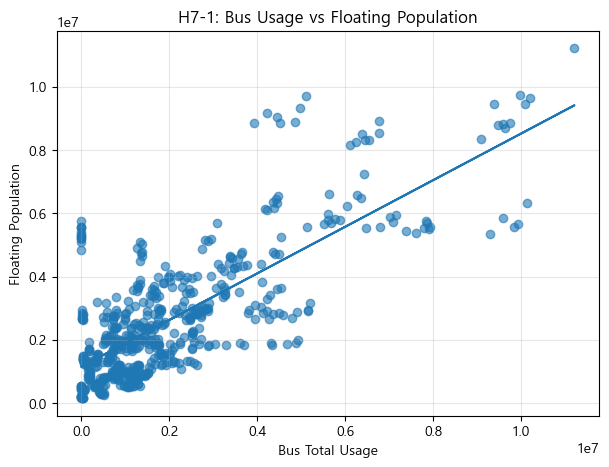

In [325]:
# 그래프로 확인해보기
x = h7_data["bus_total_usage"]
y = h7_data["floating_pop"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H7-1: Bus Usage vs Floating Population")
plt.xlabel("Bus Total Usage")
plt.ylabel("Floating Population")
plt.grid(True, alpha=0.3)
plt.show()

그래프로도 확실히 선형관계가 우상향으로 보인다 완전 일직선은 아니지만 이걸로 강한 상관관계라는 것이 확인됨.

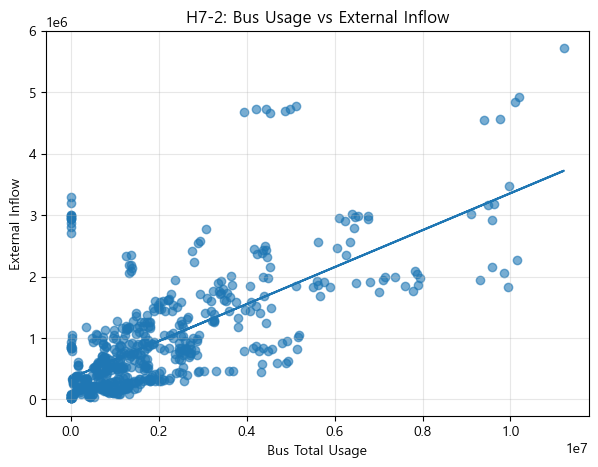

In [326]:
x = h7_data["bus_total_usage"]
y = h7_data["external_inflow"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H7-2: Bus Usage vs External Inflow")
plt.xlabel("Bus Total Usage")
plt.ylabel("External Inflow")
plt.grid(True, alpha=0.3)
plt.show()

외부유입은 유동인구보다 점들의 분산이 크지만, 전체적으로는 버스 승하차량이 증가할수록 외부유입도 증가하는 우상향 경향이 확인

그래프와 상관분석 결과 모두에서 버스 승하차량은 유동인구 및 외부유입과 강한 양의 관계를 보여, 대시보드에서 교통 접근성과 유동성 지표로 활용하기 적합

# 8. 가설: 유동인구 증가, 외부유입 증가, 체류시간 증가가 동시에 나타나는 행정동은 젠트리피케이션 위험도가 높을 것이다. 

이거는 상관관계가 아니라...... 음...... 어디동이 위험이 높은지를 보는건데....

만약 가설설정을 한다면??
- 귀무가설: 세 지표가 동시에 증가하는 곳은 젠트리피케이션 위험도와 관련이 없다.??
- 대립가설: 세 지표가 동시에 증가하는 곳은 젠트리피케이션 위험도와 관련이 있다.

In [327]:
# 세 지표의 증가율 변수 생성
main = main.sort_values(["adm_dong_nm", "base_quarter"])

main["floating_pop_growth"] = main.groupby("adm_dong_nm")["floating_pop"].pct_change()
main["external_inflow_growth"] = main.groupby("adm_dong_nm")["external_inflow"].pct_change()
main["stay_time_growth"] = main.groupby("adm_dong_nm")["stay_time_weighted"].pct_change()

In [328]:
main

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기,external_inflow_ratio,legal_key,bus_total_usage,floating_pop_growth,external_inflow_growth,stay_time_growth
180,2023Q1,2023,1,41131640,고등동,수정구,1447547.30,0.340732,0.175089,0.007172,...,8721,2931,0.336085,4112.831097,0.400527,고등동,631697.0,NaN,NaN,NaN
181,2023Q2,2023,2,41131640,고등동,수정구,1626590.55,0.345616,0.152986,0.010539,...,9396,3390,0.360792,4201.787995,0.403924,고등동,727826.0,0.123687,0.133219,-0.032642
182,2023Q3,2023,3,41131640,고등동,수정구,1705796.17,0.339101,0.153879,0.009650,...,11406,4440,0.389269,4331.404524,0.411433,고등동,711786.0,0.048694,0.068188,0.002498
183,2023Q4,2023,4,41131640,고등동,수정구,1668678.38,0.339226,0.149429,0.010227,...,12654,5232,0.413466,4383.594120,0.408237,고등동,724668.0,-0.021760,-0.029357,-0.008871
184,2024Q1,2024,1,41131640,고등동,수정구,1570351.01,0.347402,0.155271,0.007091,...,13185,5457,0.413879,4445.961320,0.402678,고등동,680118.0,-0.058925,-0.071742,0.029617
185,2024Q2,2024,2,41131640,고등동,수정구,1682321.98,0.355627,0.164790,0.009951,...,13767,5760,0.418392,4811.941599,0.411233,고등동,754024.0,0.071303,0.094064,-0.068005
186,2024Q3,2024,3,41131640,고등동,수정구,1700536.90,0.387234,0.193439,0.008082,...,12582,5244,0.416786,4544.349070,0.380239,고등동,902050.0,0.010827,-0.065357,0.035882
187,2024Q4,2024,4,41131640,고등동,수정구,1709562.65,0.390189,0.190960,0.009188,...,11088,4491,0.405032,4451.839827,0.368593,고등동,1124521.0,0.005308,-0.025484,-0.000733
188,2025Q1,2025,1,41131640,고등동,수정구,1629100.58,0.400243,0.198326,0.007288,...,10698,4281,0.400168,4749.579361,0.471028,고등동,1021002.0,-0.047066,0.217763,0.102397
189,2025Q2,2025,2,41131640,고등동,수정구,1816136.05,0.385629,0.188974,0.010136,...,10296,4179,0.405886,4912.004662,0.477590,고등동,1142593.0,0.114809,0.130338,-0.039944


In [329]:
# 그리고 세 지표가 동시에 증가한 행 생성
risk_base = main.copy()

risk_base["triple_growth_signal"] = (
    (risk_base["floating_pop_growth"] > 0) &
    (risk_base["external_inflow_growth"] > 0) &
    (risk_base["stay_time_growth"] > 0)
).astype(int)

print("동시 증가 발생 행 수:", risk_base["triple_growth_signal"].sum())
print("전체 행 수:", len(risk_base))

동시 증가 발생 행 수: 71
전체 행 수: 600


In [330]:
# 행정동별 위험 신호 횟수가 어디에 많은지
risk_summary = risk_base.groupby(
    ["gu", "adm_dong_nm"],
    as_index=False
).agg(
    signal_count=("triple_growth_signal", "sum"),
    avg_floating_growth=("floating_pop_growth", "mean"),
    avg_external_growth=("external_inflow_growth", "mean"),
    avg_stay_growth=("stay_time_growth", "mean"),
    avg_franchise_ratio=("franchise_ratio", "mean"),
    avg_open_rate=("open_rate", "mean"),
    avg_close_rate=("close_rate", "mean")
)

risk_summary = risk_summary.sort_values(
    "signal_count",
    ascending=False
)

display(risk_summary.head(20))

,gu,adm_dong_nm,signal_count,avg_floating_growth,avg_external_growth,avg_stay_growth,avg_franchise_ratio,avg_open_rate,avg_close_rate
28,수정구,시흥동,7,0.036063,0.057406,0.020886,8.195751,1.717571,1.019952
9,분당구,수내2동,4,0.067273,0.155675,0.015219,3.100418,1.378941,1.080700
27,수정구,수진2동,4,0.021408,0.041259,0.006600,4.719539,1.116069,1.127758
30,수정구,신흥1동,3,-0.002966,0.044869,0.012791,5.113475,1.333285,1.353434
4,분당구,분당동,3,0.011589,0.025714,0.004279,7.320291,1.045586,0.888191
5,분당구,삼평동,3,0.010837,0.007315,-0.001386,8.769799,1.301223,1.073614
48,중원구,중앙동,3,0.016881,0.048210,0.009937,4.308715,1.067602,1.019872
1,분당구,구미동,2,0.006219,0.009094,0.004016,7.665063,1.225613,1.087950
2,분당구,금곡동,2,0.012852,0.018767,0.004516,5.426654,1.144423,1.037751
39,중원구,금광1동,2,0.007960,0.031861,0.009636,6.394742,1.872775,1.122234


In [331]:
risk_base["floating_rank"] = risk_base["floating_pop_growth"].rank(pct=True)
risk_base["external_rank"] = risk_base["external_inflow_growth"].rank(pct=True)
risk_base["stay_rank"] = risk_base["stay_time_growth"].rank(pct=True)

risk_base["growth_pressure_score"] = risk_base[
    ["floating_rank", "external_rank", "stay_rank"]
].mean(axis=1)

In [332]:
# 행정동별 위험 평균 점수
risk_score_summary = risk_base.groupby(
    ["gu", "adm_dong_nm"],
    as_index=False
).agg(
    signal_count=("triple_growth_signal", "sum"),
    avg_growth_pressure_score=("growth_pressure_score", "mean"),
    avg_floating_growth=("floating_pop_growth", "mean"),
    avg_external_growth=("external_inflow_growth", "mean"),
    avg_stay_growth=("stay_time_growth", "mean"),
    avg_franchise_ratio=("franchise_ratio", "mean"),
    avg_open_rate=("open_rate", "mean"),
    avg_close_rate=("close_rate", "mean")
)

risk_score_summary = risk_score_summary.sort_values(
    ["signal_count", "avg_growth_pressure_score"],
    ascending=False
)

display(risk_score_summary.head(20))

,gu,adm_dong_nm,signal_count,avg_growth_pressure_score,avg_floating_growth,avg_external_growth,avg_stay_growth,avg_franchise_ratio,avg_open_rate,avg_close_rate
28,수정구,시흥동,7,0.659174,0.036063,0.057406,0.020886,8.195751,1.717571,1.019952
27,수정구,수진2동,4,0.550358,0.021408,0.041259,0.006600,4.719539,1.116069,1.127758
9,분당구,수내2동,4,0.481983,0.067273,0.155675,0.015219,3.100418,1.378941,1.080700
48,중원구,중앙동,3,0.519614,0.016881,0.048210,0.009937,4.308715,1.067602,1.019872
4,분당구,분당동,3,0.512342,0.011589,0.025714,0.004279,7.320291,1.045586,0.888191
30,수정구,신흥1동,3,0.497576,-0.002966,0.044869,0.012791,5.113475,1.333285,1.353434
5,분당구,삼평동,3,0.473774,0.010837,0.007315,-0.001386,8.769799,1.301223,1.073614
31,수정구,신흥2동,2,0.599890,0.046274,0.059902,0.008394,6.197979,1.505793,1.011923
18,분당구,정자2동,2,0.542424,0.021962,0.055828,0.007685,8.042062,0.929324,0.772573
22,수정구,고등동,2,0.538347,0.024792,0.044341,0.004022,7.842033,1.899530,0.985249


In [333]:
# 상위 위험 후보지가 어디인가??
top_risk_candidates = risk_score_summary.head(10)

display(top_risk_candidates)

,gu,adm_dong_nm,signal_count,avg_growth_pressure_score,avg_floating_growth,avg_external_growth,avg_stay_growth,avg_franchise_ratio,avg_open_rate,avg_close_rate
28,수정구,시흥동,7,0.659174,0.036063,0.057406,0.020886,8.195751,1.717571,1.019952
27,수정구,수진2동,4,0.550358,0.021408,0.041259,0.006600,4.719539,1.116069,1.127758
9,분당구,수내2동,4,0.481983,0.067273,0.155675,0.015219,3.100418,1.378941,1.080700
48,중원구,중앙동,3,0.519614,0.016881,0.048210,0.009937,4.308715,1.067602,1.019872
4,분당구,분당동,3,0.512342,0.011589,0.025714,0.004279,7.320291,1.045586,0.888191
30,수정구,신흥1동,3,0.497576,-0.002966,0.044869,0.012791,5.113475,1.333285,1.353434
5,분당구,삼평동,3,0.473774,0.010837,0.007315,-0.001386,8.769799,1.301223,1.073614
31,수정구,신흥2동,2,0.599890,0.046274,0.059902,0.008394,6.197979,1.505793,1.011923
18,분당구,정자2동,2,0.542424,0.021962,0.055828,0.007685,8.042062,0.929324,0.772573
22,수정구,고등동,2,0.538347,0.024792,0.044341,0.004022,7.842033,1.899530,0.985249


유동인구 증가율, 외부유입 증가율, 평균 체류시간 증가율이 동시에 양수로 나타나는 경우를 동시 증가 신호로 정의하였다. 이후 행정동별로 해당 신호가 몇 번 발생했는지와 세 증가율의 순위 기반 평균 점수를 계산하여 위험 후보지를 도출

유동인구, 외부유입, 체류시간이 동시에 증가하는 행정동은 외부 방문 수요와 체류형 소비 가능성이 함께 증가하는 지역으로 볼 수 있어, 젠트리피케이션 위험 후보지로 우선 모니터링할 필요가 있다.

# 9. 가설: 객단가 상승률이 카드소비 매출액 상승률보다 유의하게 높은 지역일수록 고소득층 전입이 늘어났다.

가설설정
- 귀무가설: 객단가 상승률이 카드소비 매출액 상승률의 차이는 고소득층 전입 증가율과 상관관계가 없다.
- 대립가설: 객단가 상승률이 카드소비 매출액 상승률보다 높을수록 고소득층 전입 증가율이 높아지는 상관관계가 있다.

| 구분  | 변수                          | 의미                     |
| --- | --------------------------- | ---------------------- |
| X변수 | `premium_gap`               | 객단가 상승률 - 카드소비 매출액 상승률 |
| Y변수 | `high_income_inflow_growth` | 고소득층 전입 증가율            |


In [334]:
# 정렬
main = main.sort_values(["adm_dong_nm", "base_quarter"])

# 객단가 상승률
main["avg_ticket_growth"] = main.groupby("adm_dong_nm")["avg_ticket"].pct_change()

# 카드소비 매출액 상승률
main["sales_amt_growth"] = main.groupby("adm_dong_nm")["sales_amt"].pct_change()

# 고소득층 전입 증가율
main["high_income_inflow_growth"] = main.groupby("adm_dong_nm")["전입_고소득층_인원"].pct_change()

# 객단가 상승률 - 매출액 상승률
main["premium_gap"] = main["avg_ticket_growth"] - main["sales_amt_growth"]

# 분석 데이터
h9_data = main[[
    "gu",
    "adm_dong_nm",
    "base_quarter",
    "avg_ticket_growth",
    "sales_amt_growth",
    "premium_gap",
    "전입_고소득층_인원",
    "high_income_inflow_growth"
]].replace([np.inf, -np.inf], np.nan).dropna()

print("분석 가능 행 수:", len(h9_data))
display(h9_data.head())

분석 가능 행 수: 550


,gu,adm_dong_nm,base_quarter,avg_ticket_growth,sales_amt_growth,premium_gap,전입_고소득층_인원,high_income_inflow_growth
181,수정구,고등동,2023Q2,0.031644,0.218951,-0.187307,3390,0.156602
182,수정구,고등동,2023Q3,-0.021164,-0.038729,0.017565,4440,0.309735
183,수정구,고등동,2023Q4,0.018270,-0.045687,0.063957,5232,0.178378
184,수정구,고등동,2024Q1,-0.014521,-0.089330,0.074809,5457,0.043005
185,수정구,고등동,2024Q2,0.062180,0.212762,-0.150582,5760,0.055525


In [335]:
h9_result = corr_test(
    h9_data,
    x_col="premium_gap",
    y_col="high_income_inflow_growth",
    hypothesis="H9 객단가 상승률이 카드소비 매출액 상승률보다 높은 행정동일수록 고소득층 전입 증가율이 높을 것이다",
    alternative="greater"
)

h9_result_df = pd.DataFrame([h9_result])
display(h9_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H9 객단가 상승률이 카드소비 매출액 상승률보다 높은 행정동일수록 고소득층 전입 증...,premium_gap,high_income_inflow_growth,550,-0.0921,0.9846,0.062,0.0733,약한 경향


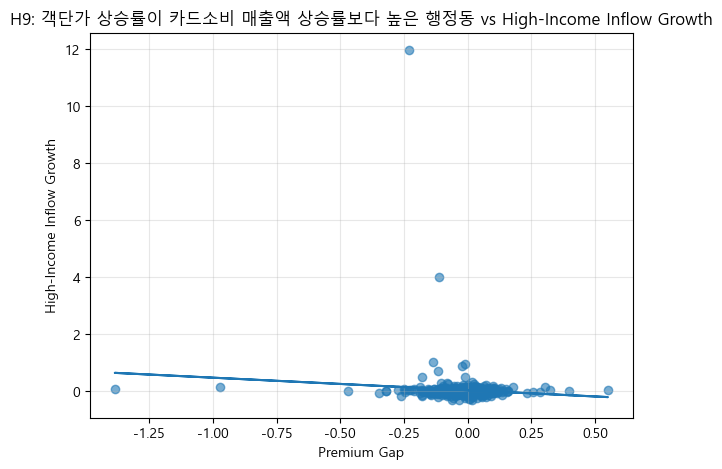

In [336]:
plot_data = h9_data[["premium_gap", "high_income_inflow_growth"]].copy()

# inf 제거 후 NaN 제거
plot_data = plot_data.replace([np.inf, -np.inf], np.nan).dropna()

x = plot_data["premium_gap"]
y = plot_data["high_income_inflow_growth"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

# 추세선
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H9: 객단가 상승률이 카드소비 매출액 상승률보다 높은 행정동 vs High-Income Inflow Growth")
plt.xlabel("Premium Gap")
plt.ylabel("High-Income Inflow Growth")
plt.grid(True, alpha=0.3)
plt.show()

pearson과 spearman으로는 잘 모르겠는데 그래프를 본결과 선형관계는 거의 없는 느낌이고 이상치 때문인지 pearson에서 약한 음수 경향이 보인다 그리고 순위기준으로는 아주 약한 양수가 있고 5%기준으로는 유의하지 않다는 결과이다.그러므로 귀무가설 기각하지 못한다.핵심지표로는 안되고 참고용으로만 사용해야 할 거 같다.

# H10. 유동인구가 높은 행정동일수록 프랜차이즈 점포수 또는 침투율이 높을 것이다.

가설설정
- 귀무가설: 유동인구와 프랜차이즈 점포수는 상관관계가 없다.
- 대립가설: 유동인구가 높을수록 프랜차이즈 점포수가 많아지는 양의 상관관계가 있다.

franchise_cnt는 점포수라서 행정동 자체가 크거나 상권 규모가 크면 당연히 많게 나올 수 있어. 그래서 이 가설은 먼저 franchise_cnt로 보고, 보조로 franchise_ratio도 같이 보면 될거 같다는 llm 추천

In [337]:
h10_1_result = corr_test(
    main,
    x_col="floating_pop",
    y_col="franchise_cnt",
    hypothesis="H10-1 유동인구가 높은 행정동일수록 프랜차이즈 점포수가 많을 것이다",
    alternative="greater"
)

h10_1_result_df = pd.DataFrame([h10_1_result])
display(h10_1_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H10-1 유동인구가 높은 행정동일수록 프랜차이즈 점포수가 많을 것이다,floating_pop,franchise_cnt,600,0.7916,0.0,0.8269,0.0,유의함


아 확실히 유동인구가 프랜차이즈랑 관련이 크다라는 결과를 도출할 수 있다. pearson 0.79로 아주강한 상관관계를 보이고 spearman도 순위에서 0.82로 더높은 상관관계가 보인다. 그리고 둘다 p값이0.0으로 귀무가설을 기각해서 유동인구가 높은 행정동은 프랜차이즈 점포수가 많다는 통계적으로 유의미하다는 결과를 알 수 있다.

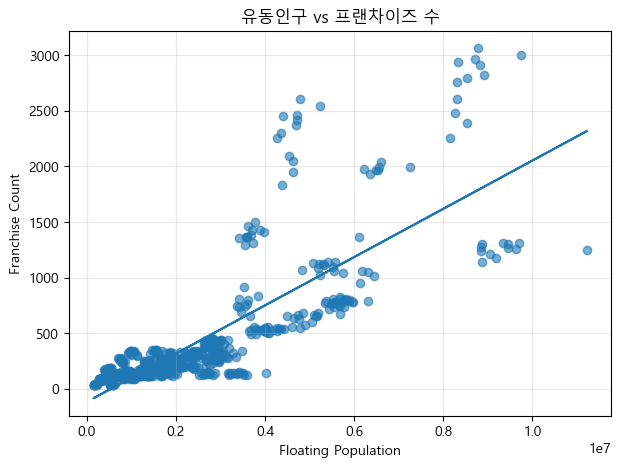

In [338]:
data = main[["floating_pop", "franchise_cnt"]].dropna()

x = data["floating_pop"]
y = data["franchise_cnt"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("유동인구 vs 프랜차이즈 수")
plt.xlabel("Floating Population")
plt.ylabel("Franchise Count")
plt.grid(True, alpha=0.3)
plt.show()

In [339]:
h10_2_result = corr_test(
    main,
    x_col="floating_pop",
    y_col="franchise_ratio",
    hypothesis="H10-2 유동인구가 높은 행정동일수록 프랜차이즈 침투율이 높을 것이다",
    alternative="greater"
)

h10_2_result_df = pd.DataFrame([h10_2_result])
display(h10_2_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H10-2 유동인구가 높은 행정동일수록 프랜차이즈 침투율이 높을 것이다,floating_pop,franchise_ratio,600,0.5225,0.0,0.5129,0.0,유의함


프랜차이즈 점포수 기준에서는 Pearson r=0.7916, Spearman rho=0.8269로 강한 양의 상관관계가 나타났고, 프랜차이즈 침투율 기준에서도 Pearson r=0.5225, Spearman rho=0.5129로 보통 수준의 양의 상관관계가 확인되었다. 따라서 유동인구가 많은 지역은 단순히 프랜차이즈 점포 수가 많은 것뿐만 아니라, 전체 상권 내 프랜차이즈 비중도 상대적으로 높은 경향이 있다고 해석할 수 있다.

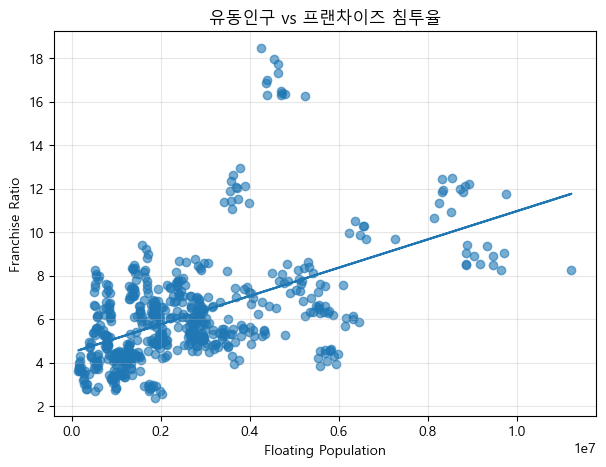

In [340]:
data1 = main[["floating_pop", "franchise_ratio"]].dropna()

x = data1["floating_pop"]
y = data1["franchise_ratio"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("유동인구 vs 프랜차이즈 침투율")
plt.xlabel("Floating Population")
plt.ylabel("Franchise Ratio")
plt.grid(True, alpha=0.3)
plt.show()

그러므로 유동인구가 젠트리피케이션에 연관이 크다라는 걸 알수 있었다.유동인구는 젠트리피케이션 위험 신호와 관련성이 높은 지표로 볼 수 있다.

# 11. 가설: 외부유입이 높은 행정동일수록 업종 다양성이 낮아질 것이다.

가설설정
- 귀무가설: 외부유입이 높다고 해서 업종 다양성이 낮아진다고 볼 수 없다.
- 대립가설: 외부유입이 많은 행정동일수록 업종 다양성이 낮다.(음의 상관관계 확인)

| 구분     | 변수        | 의미                      |
| ------ | --------- | ----------------------- |
| 독립변수 X | 외부유입 인구   | 외부에서 해당 행정동으로 들어온 방문 수요 |
| 종속변수 Y | 업종 다양성 지수 | 행정동 내 업종 분포가 얼마나 다양한지   |


이번 검정에서는 음의 상관관계를 보는것이라 alternative="less"로 확인

In [341]:
h11_base = main.copy()

h11_base["external_inflow_ratio"] = np.where(
    h11_base["floating_pop"] > 0,
    h11_base["external_inflow"] / h11_base["floating_pop"],
    np.nan
)

In [342]:
h11_data = h11_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "external_inflow",
        "floating_pop",
        "external_inflow_ratio",
        "industry_diversity_H"
    ]
].dropna()

display(h11_data.head())
display(h11_data.shape)

,base_quarter,gu,adm_dong_nm,external_inflow,floating_pop,external_inflow_ratio,industry_diversity_H
180,2023Q1,수정구,고등동,579781.51,1447547.30,0.400527,3.384395
181,2023Q2,수정구,고등동,657019.69,1626590.55,0.403924,3.389232
182,2023Q3,수정구,고등동,701820.31,1705796.17,0.411433,3.377206
183,2023Q4,수정구,고등동,681217.09,1668678.38,0.408237,3.396097
184,2024Q1,수정구,고등동,632345.40,1570351.01,0.402678,3.408606


(600, 7)

In [343]:
h11_result = corr_test(
    h11_data,
    x_col="external_inflow_ratio",
    y_col="industry_diversity_H",
    hypothesis="H11 외부유입이 높은 행정동일수록 업종 다양성이 낮아질 것이다",
    alternative="less"
)

h11_result_df = pd.DataFrame([h11_result])

display(h11_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H11 외부유입이 높은 행정동일수록 업종 다양성이 낮아질 것이다,external_inflow_ratio,industry_diversity_H,600,0.1684,0.0,0.2011,0.0,유의함


외부유입 비율과 업종 다양성 지수는 약한 양의 상관관계를 보였다. 
이는 외부유입이 높을수록 업종 다양성이 낮아질 것이라는 기존 가설과 반대되는 결과이다. 
따라서 해당 가설은 지지되지 않았으며, 오히려 외부유입이 높은 행정동일수록 업종 다양성이 높게 나타나는 경향을 확인하였다.

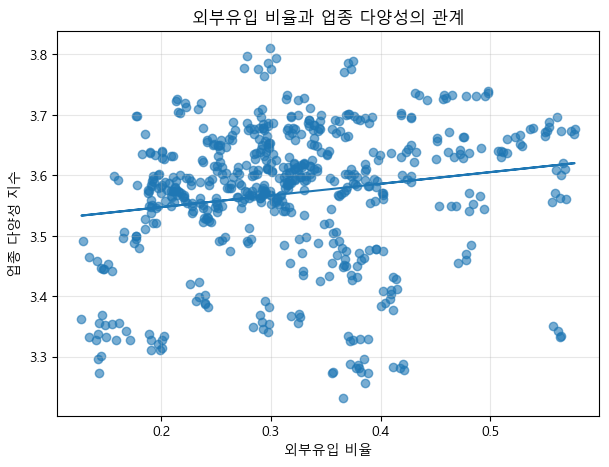

In [344]:
x = h11_data["external_inflow_ratio"]
y = h11_data["industry_diversity_H"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("외부유입 비율과 업종 다양성의 관계")
plt.xlabel("외부유입 비율")
plt.ylabel("업종 다양성 지수")
plt.grid(True, alpha=0.3)
plt.show()

# 12. 가설: 지하철 이용량이 많은 행정동일수록 외부유입 비율이 높을 것이다.

가설설정
- 귀무가설: 지하철 이용량이 많다고 해서 외부유입 비율이 높아진다고 볼 수 없다.
- 대립가설: 지하철 이용량이 많은 행정동일수록 외부유입 비율이 높다.

In [345]:
# 분석 테이블 생성
h12_base = main_subway.copy()

h12_base["external_inflow_ratio"] = np.where(
    h12_base["floating_pop"] > 0,
    h12_base["external_inflow"] / h12_base["floating_pop"],
    np.nan
)

h12_data = h12_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "subway_total_usage",
        "external_inflow_ratio"
    ]
].dropna()

display(h12_data.head())
display(h12_data.shape)

,base_quarter,gu,adm_dong_nm,subway_total_usage,external_inflow_ratio
0,2023Q1,수정구,신흥1동,906726.0,0.185027
1,2023Q2,수정구,신흥1동,941838.0,0.176825
2,2023Q3,수정구,신흥1동,909599.0,0.176573
3,2023Q4,수정구,신흥1동,934146.0,0.179537
4,2024Q1,수정구,신흥1동,928985.0,0.174966


(600, 5)

In [346]:
h12_result = corr_test(
    h12_data,
    x_col="subway_total_usage",
    y_col="external_inflow_ratio",
    hypothesis="H12 지하철 이용량이 많은 행정동일수록 외부유입 비율이 높을 것이다",
    alternative="greater"
)

h12_result_df = pd.DataFrame([h12_result])
display(h12_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H12 지하철 이용량이 많은 행정동일수록 외부유입 비율이 높을 것이다,subway_total_usage,external_inflow_ratio,600,0.2052,0.0,0.2051,0.0,유의함


지하철 이용량과 외부유입 비율은 Pearson 0.2052, Spearman 0.2051로 약한 양의 상관관계를 보였다. 
p-value가 0.05보다 작아 통계적으로 유의했으며, 따라서 지하철 이용량이 많은 행정동일수록 외부유입 비율이 높을 것이라는 가설은 지지된다

# H13. 가설: 버스 승하차 이용량과 소비 수준은 관련이 있다.

가설설정
- H13-1 귀무가설: 버스 승하차 이용량과 매출액 사이에는 상관관계가 없다.
- H13-1 대립가설: 버스 승하차 이용량과 매출액 사이에는 상관관계가 있다.
- H13-2 귀무가설: 버스 승하차 이용량과 객단가 사이에는 상관관계가 없다.
- H13-2 대립가설: 버스 승하차 이용량과 객단가 사이에는 상관관계가 있다.

In [347]:
# 버스 총이용량 컬럼이 없어 생성
h13_base = main.copy()

h13_base["bus_total_usage"] = (
    h13_base["bus_board_cnt"] + h13_base["bus_alight_cnt"]
)

In [348]:
# 분석 테이블 생성
h13_data = h13_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "bus_total_usage",
        "sales_amt",
        "avg_ticket"
    ]
].dropna()

display(h13_data.head())
display(h13_data.shape)

,base_quarter,gu,adm_dong_nm,bus_total_usage,sales_amt,avg_ticket
180,2023Q1,수정구,고등동,631697.0,1.885877e+10,24877.906558
181,2023Q2,수정구,고등동,727826.0,2.298791e+10,25665.148781
182,2023Q3,수정구,고등동,711786.0,2.209761e+10,25121.965791
183,2023Q4,수정구,고등동,724668.0,2.108804e+10,25580.952859
184,2024Q1,수정구,고등동,680118.0,1.920424e+10,25209.499818


(600, 6)

In [349]:
h13_tests = [
    corr_test(
        h13_data,
        x_col="bus_total_usage",
        y_col="sales_amt",
        hypothesis="H13-1 버스 승하차 이용량과 매출액은 관련이 있을 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h13_data,
        x_col="bus_total_usage",
        y_col="avg_ticket",
        hypothesis="H13-2 버스 승하차 이용량과 객단가는 관련이 있을 것이다",
        alternative="two-sided"
    )
]

h13_result_df = pd.DataFrame(h13_tests)
display(h13_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H13-1 버스 승하차 이용량과 매출액은 관련이 있을 것이다,bus_total_usage,sales_amt,600,0.2911,0.0,0.5385,0.0,유의함
1,H13-2 버스 승하차 이용량과 객단가는 관련이 있을 것이다,bus_total_usage,avg_ticket,600,0.2745,0.0,0.3312,0.0,유의함


H13 검정 결과, 버스 승하차 이용량은 매출액(`sales_amt`)과 객단가(`avg_ticket`) 모두와 통계적으로 유의한 관련이 있는 것으로 나타났다. H13-1은 Pearson 0.2911, Spearman 0.5385로 유의하고, H13-2는 Pearson 0.2745, Spearman 0.3312로 유의하다. 따라서 버스 이용량과 소비 수준의 관련성은 지지된다.

# 14. 가설: 방문 목적 또는 이동 수단 비중이 변한 동은 상권 기능이 변화 했을 가능성이 있다.

가설설정
- 귀무가설: 방문 목적 및 이동 수단 비중 변화와 상권 기능 지표 변화 사이에는 유의한 관계가 없다.
- 대립가설: 방문 목적 및 이동 수단 비중 변화와 상권 기능 지표 변화 사이에는 유의한 관계가 있다.

이거는 1개씩 다 쪼개서 확인해야 할 거 같습니다.

- H14-1. 방문 목적 비중 변화가 큰 행정동일수록 업종 다양성 변화도 클 것이다.
- H14-2. 방문 목적 비중 변화가 큰 행정동일수록 신생점포 잔존율 변화도 클 것이다.
- H14-3. 방문 목적 비중 변화가 큰 행정동일수록 개업률 변화도 클 것이다.
- H14-4. 방문 목적 비중 변화가 큰 행정동일수록 폐업률 변화도 클 것이다.

- H14-5. 이동 수단 비중 변화가 큰 행정동일수록 업종 다양성 변화도 클 것이다.
- H14-6. 이동 수단 비중 변화가 큰 행정동일수록 신생점포 잔존율 변화도 클 것이다.
- H14-7. 이동 수단 비중 변화가 큰 행정동일수록 개업률 변화도 클 것이다.
- H14-8. 이동 수단 비중 변화가 큰 행정동일수록 폐업률 변화도 클 것이다.

| 변수                       | 의미           |
| ------------------------ | ------------ |
| `purpose_change_score`   | 방문 목적 비중 변화량 |
| `transport_change_score` | 이동 수단 비중 변화량 |


| 변수                              | 의미           |
| ------------------------------- | ------------ |
| `industry_diversity_change_abs` | 업종 다양성 변화량   |
| `survival_rate_change_abs`      | 신생점포 잔존율 변화량 |
| `open_rate_change_abs`          | 개업률 변화량      |
| `close_rate_change_abs`         | 폐업률 변화량      |


In [350]:
purpose_cols = [
    col for col in main.columns 
    if col.startswith("purpose_") and col.endswith("_ratio")
]

transport_cols = [
    col for col in main.columns 
    if col.startswith("transport_") and col.endswith("_ratio")
]

h14_base = main.copy()

h14_base = h14_base.sort_values(
    ["gu", "adm_dong_nm", "year", "quarter"]
).reset_index(drop=True)

# 방문 목적 변화량
purpose_diff = (
    h14_base
    .groupby(["gu", "adm_dong_nm"])[purpose_cols]
    .diff()
    .abs()
)

h14_base["purpose_change_score"] = purpose_diff.sum(axis=1, min_count=1)

# 이동 수단 변화량
transport_diff = (
    h14_base
    .groupby(["gu", "adm_dong_nm"])[transport_cols]
    .diff()
    .abs()
)

h14_base["transport_change_score"] = transport_diff.sum(axis=1, min_count=1)

# 업종 다양성 변화량
h14_base["industry_diversity_change_abs"] = (
    h14_base
    .groupby(["gu", "adm_dong_nm"])["industry_diversity_H"]
    .diff()
    .abs()
)

# 신생점포 잔존율 변화량
h14_base["survival_rate_change_abs"] = (
    h14_base
    .groupby(["gu", "adm_dong_nm"])["survival_rate_1y"]
    .diff()
    .abs()
)

# 개업률 변화량
h14_base["open_rate_change_abs"] = (
    h14_base
    .groupby(["gu", "adm_dong_nm"])["open_rate"]
    .diff()
    .abs()
)

# 폐업률 변화량
h14_base["close_rate_change_abs"] = (
    h14_base
    .groupby(["gu", "adm_dong_nm"])["close_rate"]
    .diff()
    .abs()
)

In [351]:
h14_check_cols = [
    "base_quarter",
    "gu",
    "adm_dong_nm",
    "purpose_change_score",
    "transport_change_score",
    "industry_diversity_change_abs",
    "survival_rate_change_abs",
    "open_rate_change_abs",
    "close_rate_change_abs"
]

display(h14_base[h14_check_cols].head(15))

,base_quarter,gu,adm_dong_nm,purpose_change_score,transport_change_score,industry_diversity_change_abs,survival_rate_change_abs,open_rate_change_abs,close_rate_change_abs
0,2023Q1,분당구,구미1동,NaN,NaN,NaN,NaN,NaN,NaN
1,2023Q2,분당구,구미1동,0.015394,0.005907,0.004428,NaN,0.168845,0.076041
2,2023Q3,분당구,구미1동,0.024614,0.014143,0.010782,NaN,0.350977,0.890936
3,2023Q4,분당구,구미1동,0.019150,0.049825,0.010671,NaN,0.225328,1.353906
4,2024Q1,분당구,구미1동,0.022716,0.035679,0.008375,NaN,0.121410,0.421802
5,2024Q2,분당구,구미1동,0.091287,0.072389,0.006515,6.322435,0.424047,0.294506
6,2024Q3,분당구,구미1동,0.104531,0.163480,0.001781,1.226615,0.390660,0.047712
7,2024Q4,분당구,구미1동,0.020570,0.018494,0.004998,5.901087,0.017603,0.184218
8,2025Q1,분당구,구미1동,0.019349,0.036111,0.003691,3.144374,0.147297,0.377590
9,2025Q2,분당구,구미1동,0.022211,0.024078,0.001530,3.010753,0.104395,0.256250


In [352]:
h14_data = h14_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "purpose_change_score",
        "transport_change_score",
        "industry_diversity_change_abs",
        "survival_rate_change_abs",
        "open_rate_change_abs",
        "close_rate_change_abs"
    ]
].dropna()

display(h14_data.head())
display(h14_data.shape)

,base_quarter,gu,adm_dong_nm,purpose_change_score,transport_change_score,industry_diversity_change_abs,survival_rate_change_abs,open_rate_change_abs,close_rate_change_abs
5,2024Q2,분당구,구미1동,0.091287,0.072389,0.006515,6.322435,0.424047,0.294506
6,2024Q3,분당구,구미1동,0.104531,0.163480,0.001781,1.226615,0.390660,0.047712
7,2024Q4,분당구,구미1동,0.020570,0.018494,0.004998,5.901087,0.017603,0.184218
8,2025Q1,분당구,구미1동,0.019349,0.036111,0.003691,3.144374,0.147297,0.377590
9,2025Q2,분당구,구미1동,0.022211,0.024078,0.001530,3.010753,0.104395,0.256250


(350, 9)

In [353]:
h14_results = [
    corr_test(
        h14_data,
        x_col="purpose_change_score",
        y_col="industry_diversity_change_abs",
        hypothesis="H14-1 방문 목적 비중 변화가 큰 행정동일수록 업종 다양성 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="purpose_change_score",
        y_col="survival_rate_change_abs",
        hypothesis="H14-2 방문 목적 비중 변화가 큰 행정동일수록 신생점포 잔존율 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="purpose_change_score",
        y_col="open_rate_change_abs",
        hypothesis="H14-3 방문 목적 비중 변화가 큰 행정동일수록 개업률 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="purpose_change_score",
        y_col="close_rate_change_abs",
        hypothesis="H14-4 방문 목적 비중 변화가 큰 행정동일수록 폐업률 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="transport_change_score",
        y_col="industry_diversity_change_abs",
        hypothesis="H14-5 이동 수단 비중 변화가 큰 행정동일수록 업종 다양성 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="transport_change_score",
        y_col="survival_rate_change_abs",
        hypothesis="H14-6 이동 수단 비중 변화가 큰 행정동일수록 신생점포 잔존율 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="transport_change_score",
        y_col="open_rate_change_abs",
        hypothesis="H14-7 이동 수단 비중 변화가 큰 행정동일수록 개업률 변화도 클 것이다",
        alternative="two-sided"
    ),
    corr_test(
        h14_data,
        x_col="transport_change_score",
        y_col="close_rate_change_abs",
        hypothesis="H14-8 이동 수단 비중 변화가 큰 행정동일수록 폐업률 변화도 클 것이다",
        alternative="two-sided"
    )
]

h14_result_df = pd.DataFrame(h14_results)
display(h14_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H14-1 방문 목적 비중 변화가 큰 행정동일수록 업종 다양성 변화도 클 것이다,purpose_change_score,industry_diversity_change_abs,350,0.1475,0.0057,0.0981,0.0667,약한 경향
1,H14-2 방문 목적 비중 변화가 큰 행정동일수록 신생점포 잔존율 변화도 클 것이다,purpose_change_score,survival_rate_change_abs,350,0.2154,0.0000,0.1781,0.0008,유의함
2,H14-3 방문 목적 비중 변화가 큰 행정동일수록 개업률 변화도 클 것이다,purpose_change_score,open_rate_change_abs,350,0.0956,0.0740,0.1324,0.0132,유의함
3,H14-4 방문 목적 비중 변화가 큰 행정동일수록 폐업률 변화도 클 것이다,purpose_change_score,close_rate_change_abs,350,0.1242,0.0201,0.0860,0.1082,유의하지 않음
4,H14-5 이동 수단 비중 변화가 큰 행정동일수록 업종 다양성 변화도 클 것이다,transport_change_score,industry_diversity_change_abs,350,0.2167,0.0000,0.1281,0.0165,유의함
5,H14-6 이동 수단 비중 변화가 큰 행정동일수록 신생점포 잔존율 변화도 클 것이다,transport_change_score,survival_rate_change_abs,350,0.0582,0.2779,0.0784,0.1433,유의하지 않음
6,H14-7 이동 수단 비중 변화가 큰 행정동일수록 개업률 변화도 클 것이다,transport_change_score,open_rate_change_abs,350,0.1156,0.0306,0.1783,0.0008,유의함
7,H14-8 이동 수단 비중 변화가 큰 행정동일수록 폐업률 변화도 클 것이다,transport_change_score,close_rate_change_abs,350,0.1365,0.0106,0.0755,0.1586,유의하지 않음


Pearson/Spearman 상관분석만으로는 관계가 약하거나 애매하게 보여서, 방문 목적 변화가 큰 집단과 작은 집단을 나눠서 상권 기능 변화량이 실제로 차이 나는지 더 확실히 보고 싶다.

새로운 가설: 방문목적 변화가 큰 동과 작은 동은 업종 다양성 변화량 평균이 다른지??

### 방문 목적 변화 큰 그룹 vs 방문 목적 변화 작은 그룹

서로 다른 행이 두 그룹으로 나뉘니깐 독립표본 검정으로 한다.

가설 설정
- 귀무가설: 방문 목적 변화가 큰그룹과 작은 그룹의 업종 다양성 변화량의 평균에는 차이가 없다.
- 대립가설: 방문 목적 변화가 큰그룹과 작은 그룹의 업종 다양성 변화량에는 평균에 차이가 있다.

일단 큰그룹과 작은그룹을 상위 25% 하위25%로 나눈 후 검정

In [354]:
h14_ttest = h14_data.copy()

q75 = h14_ttest["purpose_change_score"].quantile(0.75)
q25 = h14_ttest["purpose_change_score"].quantile(0.25)

high_purpose = h14_ttest[h14_ttest["purpose_change_score"] >= q75]
low_purpose = h14_ttest[h14_ttest["purpose_change_score"] <= q25]

print("방문 목적 변화 상위 25% 기준값:", q75)
print("방문 목적 변화 하위 25% 기준값:", q25)

print("방문 목적 변화 큰 그룹:", high_purpose.shape)
print("방문 목적 변화 작은 그룹:", low_purpose.shape)

display(
    high_purpose[
        ["base_quarter", "gu", "adm_dong_nm", "purpose_change_score", "industry_diversity_change_abs"]
    ].head()
)

display(
    low_purpose[
        ["base_quarter", "gu", "adm_dong_nm", "purpose_change_score", "industry_diversity_change_abs"]
    ].head()
)

방문 목적 변화 상위 25% 기준값: 0.09666864775200956
방문 목적 변화 하위 25% 기준값: 0.022658388797598832
방문 목적 변화 큰 그룹: (88, 9)
방문 목적 변화 작은 그룹: (88, 9)


,base_quarter,gu,adm_dong_nm,purpose_change_score,industry_diversity_change_abs
6,2024Q3,분당구,구미1동,0.104531,0.001781
17,2024Q2,분당구,구미동,0.109926,0.002405
18,2024Q3,분당구,구미동,0.128805,0.011983
29,2024Q2,분당구,금곡동,0.106569,0.004266
41,2024Q2,분당구,백현동,0.097606,0.055062


,base_quarter,gu,adm_dong_nm,purpose_change_score,industry_diversity_change_abs
7,2024Q4,분당구,구미1동,0.020570,0.004998
8,2025Q1,분당구,구미1동,0.019349,0.003691
9,2025Q2,분당구,구미1동,0.022211,0.001530
10,2025Q3,분당구,구미1동,0.018157,0.009656
11,2025Q4,분당구,구미1동,0.014522,0.002463


잘나눠진거 확인했고 이제 정규성을 띄는지 확인

In [355]:
from scipy.stats import shapiro

y_col = "industry_diversity_change_abs"

high = high_purpose[y_col].dropna()
low = low_purpose[y_col].dropna()

shapiro_high = shapiro(high)
shapiro_low = shapiro(low)

print("큰 그룹 n:", len(high))
print("작은 그룹 n:", len(low))

print("큰 그룹 정규성 p-value:", shapiro_high.pvalue)
print("작은 그룹 정규성 p-value:", shapiro_low.pvalue)

큰 그룹 n: 88
작은 그룹 n: 88
큰 그룹 정규성 p-value: 1.7316408027064757e-09
작은 그룹 정규성 p-value: 8.368735311680535e-08


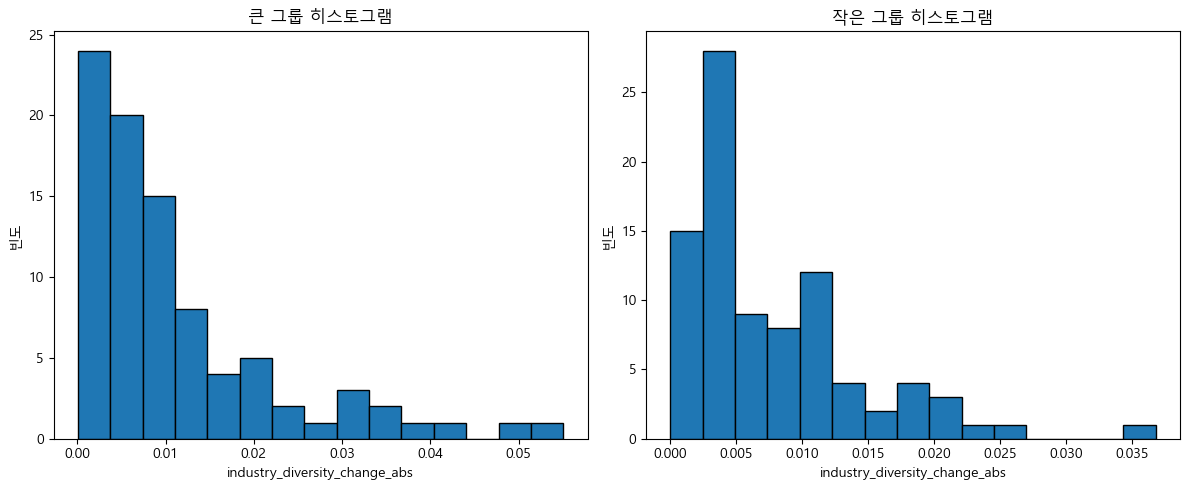

In [356]:
plt.figure(figsize=(12, 5))

# 큰 그룹 히스토그램
plt.subplot(1, 2, 1)
plt.hist(high, bins=15, edgecolor="black")
plt.title("큰 그룹 히스토그램")
plt.xlabel("industry_diversity_change_abs")
plt.ylabel("빈도")

# 작은 그룹 히스토그램
plt.subplot(1, 2, 2)
plt.hist(low, bins=15, edgecolor="black")
plt.title("작은 그룹 히스토그램")
plt.xlabel("industry_diversity_change_abs")
plt.ylabel("빈도")

plt.tight_layout()
plt.show()

In [357]:
import matplotlib.pyplot as plt
from scipy.stats import probplot

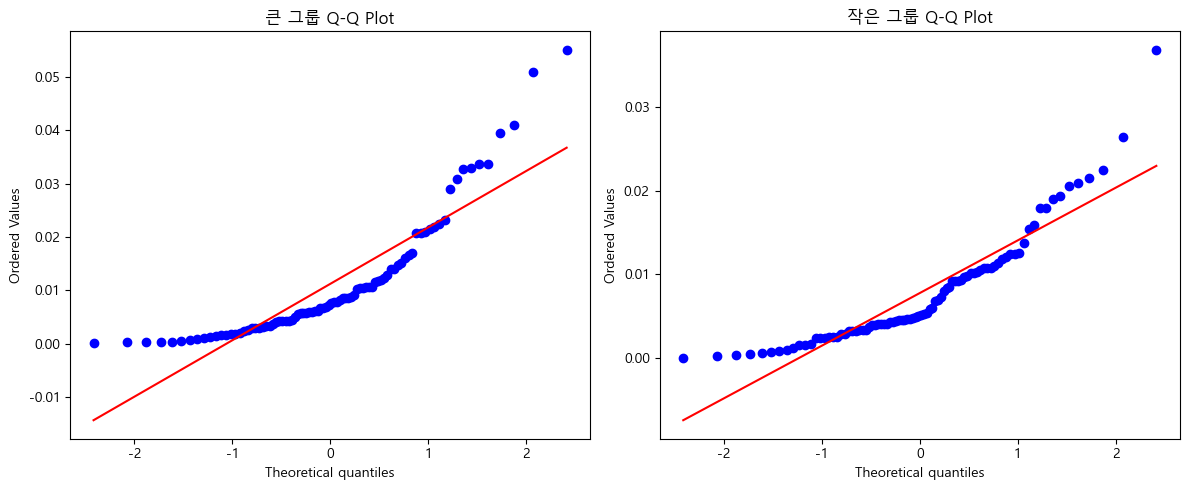

In [358]:
plt.figure(figsize=(12, 5))

# 큰 그룹 QQ plot
plt.subplot(1, 2, 1)
probplot(high, dist="norm", plot=plt)
plt.title("큰 그룹 Q-Q Plot")

# 작은 그룹 QQ plot
plt.subplot(1, 2, 2)
probplot(low, dist="norm", plot=plt)
plt.title("작은 그룹 Q-Q Plot")

plt.tight_layout()
plt.show()

확인결과 정규성을 만족하지 않음...

그러므로  맨 휘트니 u검정 실시

In [359]:
from scipy.stats import mannwhitneyu
import pandas as pd

y_col = "industry_diversity_change_abs"

high = high_purpose[y_col].dropna()
low = low_purpose[y_col].dropna()

u_stat, p_value = mannwhitneyu(
    high,
    low,
    alternative="two-sided"
)

result_mw = pd.DataFrame([{
    "검정": "Mann-Whitney U test",
    "비교": "방문 목적 변화 큰 그룹 vs 작은 그룹",
    "Y변수": y_col,
    "큰그룹_n": len(high),
    "작은그룹_n": len(low),
    "큰그룹_평균": high.mean(),
    "작은그룹_평균": low.mean(),
    "큰그룹_중앙값": high.median(),
    "작은그룹_중앙값": low.median(),
    "U_stat": u_stat,
    "p_value": p_value
}])

display(result_mw)

,검정,비교,Y변수,큰그룹_n,작은그룹_n,큰그룹_평균,작은그룹_평균,큰그룹_중앙값,작은그룹_중앙값,U_stat,p_value
0,Mann-Whitney U test,방문 목적 변화 큰 그룹 vs 작은 그룹,industry_diversity_change_abs,88,88,0.011175,0.007772,0.007368,0.005105,4346.0,0.161211


정규성 가정이 충족되지 않아 비모수 검정인 Mann-Whitney U test를 추가로 수행하였다. Mann-Whitney U test 결과 p-value는 0.1612로 유의수준 0.05보다 커, 두 집단 간 차이가 통계적으로 유의하다고 보기는 어려웠다.

방문 목적 변화가 큰 그룹은 작은 그룹보다 업종 다양성 변화량의 평균과 중앙값이 모두 높게 나타났다. 그러나 정규성 가정이 충분히 충족되지 않았고, 비모수 검정 결과 p-value가 0.05보다 크게 나타나 통계적으로 유의한 차이로 보기는 어렵다. 따라서 방문 목적 변화가 큰 행정동일수록 업종 다양성 변화가 더 크다는 가설은 강하게 지지되지는 않는다.

상관분석만으로는 관계가 약하거나 일관되지 않게 나타났기 때문에,
방문 목적 변화량과 이동 수단 변화량을 기준으로 상위 25% 집단과 하위 25% 집단을 구분하였다.
이후 각 집단의 상권 기능 지표 변화량 차이를 Mann-Whitney U test로 검정하였다.

In [360]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import pandas as pd

def group_compare_test(data, x_col, y_col, x_label, y_label):
    # 1. 상위 25%, 하위 25% 기준값
    q75 = data[x_col].quantile(0.75)
    q25 = data[x_col].quantile(0.25)

    # 2. 큰 그룹 / 작은 그룹 나누기
    high_group = data[data[x_col] >= q75][y_col].dropna()
    low_group = data[data[x_col] <= q25][y_col].dropna()

    # 3. 정규성 검정
    shapiro_high_p = shapiro(high_group).pvalue if len(high_group) >= 3 else None
    shapiro_low_p = shapiro(low_group).pvalue if len(low_group) >= 3 else None

    # 4. 등분산성 검정
    levene_p = levene(high_group, low_group).pvalue

    # 5. Welch t-test
    welch_t, welch_p = ttest_ind(
        high_group,
        low_group,
        equal_var=False
    )

    # 6. Mann-Whitney U test
    u_stat, mw_p = mannwhitneyu(
        high_group,
        low_group,
        alternative="two-sided"
    )

    return {
        "X기준": x_label,
        "Y변수": y_label,
        "큰그룹_n": len(high_group),
        "작은그룹_n": len(low_group),
        "큰그룹_평균": high_group.mean(),
        "작은그룹_평균": low_group.mean(),
        "큰그룹_중앙값": high_group.median(),
        "작은그룹_중앙값": low_group.median(),
        "평균차이": high_group.mean() - low_group.mean(),
        "중앙값차이": high_group.median() - low_group.median(),
        "큰그룹_정규성_p": shapiro_high_p,
        "작은그룹_정규성_p": shapiro_low_p,
        "등분산성_p": levene_p,
        "Welch_p": welch_p,
        "MannWhitney_p": mw_p,
        "비모수_판정": "유의함" if mw_p < 0.05 else "유의하지 않음"
    }

In [361]:
targets = [
    ("industry_diversity_change_abs", "업종 다양성 변화"),
    ("survival_rate_change_abs", "신생점포 잔존율 변화"),
    ("open_rate_change_abs", "개업률 변화"),
    ("close_rate_change_abs", "폐업률 변화")
]

results = []

for y_col, y_label in targets:
    results.append(
        group_compare_test(
            h14_data,
            x_col="purpose_change_score",
            y_col=y_col,
            x_label="방문 목적 변화",
            y_label=y_label
        )
    )

for y_col, y_label in targets:
    results.append(
        group_compare_test(
            h14_data,
            x_col="transport_change_score",
            y_col=y_col,
            x_label="이동 수단 변화",
            y_label=y_label
        )
    )

h14_group_test_df = pd.DataFrame(results)
display(h14_group_test_df)

,X기준,Y변수,큰그룹_n,작은그룹_n,큰그룹_평균,작은그룹_평균,큰그룹_중앙값,작은그룹_중앙값,평균차이,중앙값차이,큰그룹_정규성_p,작은그룹_정규성_p,등분산성_p,Welch_p,MannWhitney_p,비모수_판정
0,방문 목적 변화,업종 다양성 변화,88,88,0.011175,0.007772,0.007368,0.005105,0.003402,0.002263,1.731641e-09,8.368735e-08,0.010164,0.018583,0.161211,유의하지 않음
1,방문 목적 변화,신생점포 잔존율 변화,88,88,8.632259,5.428187,6.575417,4.983211,3.204072,1.592206,1.466847e-04,3.274006e-03,0.000002,0.000072,0.002411,유의함
2,방문 목적 변화,개업률 변화,88,88,0.410707,0.378628,0.371716,0.251875,0.032079,0.119841,5.743565e-04,3.134072e-07,0.221169,0.496907,0.124265,유의하지 않음
3,방문 목적 변화,폐업률 변화,88,88,0.278918,0.230240,0.249554,0.191782,0.048678,0.057772,2.761950e-08,3.140806e-07,0.033431,0.138816,0.308051,유의하지 않음
4,이동 수단 변화,업종 다양성 변화,88,88,0.010824,0.007545,0.006780,0.005617,0.003279,0.001163,4.249431e-09,2.307779e-08,0.010988,0.018784,0.141816,유의하지 않음
5,이동 수단 변화,신생점포 잔존율 변화,88,88,8.053584,5.818758,6.246364,5.529303,2.234826,0.717061,1.688988e-05,2.379094e-04,0.000049,0.006214,0.102100,유의하지 않음
6,이동 수단 변화,개업률 변화,88,88,0.439300,0.327216,0.390276,0.243960,0.112084,0.146315,8.228370e-05,1.070728e-07,0.559671,0.018682,0.004484,유의함
7,이동 수단 변화,폐업률 변화,88,88,0.273543,0.225920,0.194933,0.189392,0.047624,0.005541,1.346818e-08,6.840718e-05,0.004413,0.138180,0.575002,유의하지 않음


# 15. 가설: 프랜차이즈 침투율이 높을수록 객단가의 변동성이 작아지는가?

가설설정
- 귀무가설: 프랜차이즈 침투율이 높아져도 객단가 변동성이 작아진다고 볼 수 없다.
- 대립가설: 프랜차이즈 침투율이 높아질수록 객단가 변동성은 유의하게 작아진다.

- 본 가설은 프랜차이즈 침투율이 높은 지역에서 객단가가 더 표준화되어 나타나는지를 확인하기 위한 것이다.
- 따라서 원자료 `avg_ticket`의 분산을 바로 비교하지 않고, 행정동별 시간 흐름에서의 객단가 표준편차를 `avg_ticket_volatility`로 먼저 만든 뒤 비교한다.
- 프랜차이즈 침투율은 행정동별 평균값을 사용하고, 상위 25% 집단과 하위 25% 집단의 객단가 변동성 차이를 검정한다.

행정동별 여러 분기 관측치가 있으므로 `avg_ticket`의 행정동별 표준편차를 객단가 변동성 변수로 생성한다.

In [362]:
h15_data = (
    main
    .groupby(["gu", "adm_dong_nm"], as_index=False)
    .agg(
        franchise_ratio=("franchise_ratio", "mean"),
        avg_ticket_mean=("avg_ticket", "mean"),
        avg_ticket_volatility=("avg_ticket", "std"),
        obs_n=("avg_ticket", "count")
    )
    .dropna(subset=["franchise_ratio", "avg_ticket_volatility"])
)

q75 = h15_data["franchise_ratio"].quantile(0.75)
q25 = h15_data["franchise_ratio"].quantile(0.25)

high_franchise = h15_data[h15_data["franchise_ratio"] >= q75]
low_franchise = h15_data[h15_data["franchise_ratio"] <= q25]

print("프랜차이즈 침투율 상위 25% 기준값:", q75)
print("프랜차이즈 침투율 하위 25% 기준값:", q25)

print("프랜차이즈 높은 그룹:", high_franchise.shape)
print("프랜차이즈 낮은 그룹:", low_franchise.shape)

display(
    high_franchise[
        ["gu", "adm_dong_nm", "franchise_ratio", "avg_ticket_mean", "avg_ticket_volatility", "obs_n"]
    ].head()
)

display(
    low_franchise[
        ["gu", "adm_dong_nm", "franchise_ratio", "avg_ticket_mean", "avg_ticket_volatility", "obs_n"]
    ].head()
)

프랜차이즈 침투율 상위 25% 기준값: 7.1851242864589695
프랜차이즈 침투율 하위 25% 기준값: 4.572922368773309
프랜차이즈 높은 그룹: (13, 6)
프랜차이즈 낮은 그룹: (13, 6)


,gu,adm_dong_nm,franchise_ratio,avg_ticket_mean,avg_ticket_volatility,obs_n
1,분당구,구미동,7.665063,44586.713426,2480.761870,12
3,분당구,백현동,16.960166,30083.157607,1862.188097,12
4,분당구,분당동,7.320291,22981.073645,1389.605024,12
5,분당구,삼평동,8.769799,25721.071499,4337.498100,12
6,분당구,서현1동,11.799827,51029.490877,7153.632928,12


,gu,adm_dong_nm,franchise_ratio,avg_ticket_mean,avg_ticket_volatility,obs_n
9,분당구,수내2동,3.100418,28348.825521,1161.352385,12
12,분당구,야탑2동,4.214892,27910.101809,1760.039958,12
23,수정구,단대동,4.124298,21869.658029,731.547599,12
26,수정구,수진1동,3.128782,25516.288796,986.061280,12
29,수정구,신촌동,3.986062,26844.822214,2107.110444,12


왜 상위/하위 25%로 나누냐면, 중간 애들까지 다 넣으면 차이가 흐려질 수 있어서
우리는 “프랜차이즈가 확실히 많은 지역”과 “확실히 적은 지역”의 객단가 변동성을 비교

In [363]:
# 검정 전에 객단가 변동성 차이 확인
high_volatility = high_franchise["avg_ticket_volatility"].dropna()
low_volatility = low_franchise["avg_ticket_volatility"].dropna()

print("프랜차이즈 높은 그룹 n:", len(high_volatility))
print("프랜차이즈 낮은 그룹 n:", len(low_volatility))

print()
print("[프랜차이즈 높은 그룹]")
print("평균 변동성:", high_volatility.mean())
print("중앙값 변동성:", high_volatility.median())
print("표준편차:", high_volatility.std())

print()
print("[프랜차이즈 낮은 그룹]")
print("평균 변동성:", low_volatility.mean())
print("중앙값 변동성:", low_volatility.median())
print("표준편차:", low_volatility.std())

프랜차이즈 높은 그룹 n: 13
프랜차이즈 낮은 그룹 n: 13

[프랜차이즈 높은 그룹]
평균 변동성: 2409.663872498178
중앙값 변동성: 1860.9269578274518
표준편차: 1809.3412584668488

[프랜차이즈 낮은 그룹]
평균 변동성: 1135.298092052627
중앙값 변동성: 986.0612795561954
표준편차: 553.1878289075053


높은 그룹의 객단가 변동성 평균과 중앙값이 낮은 그룹보다 작은지 먼저 방향성을 확인한다.

프랜차이즈 침투율 그룹별 `avg_ticket_volatility`를 비교하므로, 이후 검정 결과의 방향은 “높은 그룹 변동성 < 낮은 그룹 변동성”인지로 판단한다.

In [364]:
from scipy.stats import mannwhitneyu, ttest_ind

high_volatility = high_franchise["avg_ticket_volatility"].dropna()
low_volatility = low_franchise["avg_ticket_volatility"].dropna()

# H15 방향: 프랜차이즈 높은 그룹의 객단가 변동성이 더 낮다.
u_stat, mw_p = mannwhitneyu(
    high_volatility,
    low_volatility,
    alternative="less"
)

welch_t, welch_p_two = ttest_ind(
    high_volatility,
    low_volatility,
    equal_var=False
)
welch_p_less = welch_p_two / 2 if welch_t < 0 else 1 - (welch_p_two / 2)

h15_volatility_test_df = pd.DataFrame([{
    "가설": "H15 프랜차이즈 침투율이 높은 행정동일수록 객단가 변동성은 낮을 것이다",
    "높은그룹_n": len(high_volatility),
    "낮은그룹_n": len(low_volatility),
    "높은그룹_변동성_평균": high_volatility.mean(),
    "낮은그룹_변동성_평균": low_volatility.mean(),
    "높은그룹_변동성_중앙값": high_volatility.median(),
    "낮은그룹_변동성_중앙값": low_volatility.median(),
    "Welch_t": welch_t,
    "Welch_p_less": welch_p_less,
    "MannWhitney_U": u_stat,
    "MannWhitney_p_less": mw_p,
    "방향": "가설 방향 일치" if high_volatility.mean() < low_volatility.mean() else "가설 반대"
}])

display(h15_volatility_test_df)

,가설,높은그룹_n,낮은그룹_n,높은그룹_변동성_평균,낮은그룹_변동성_평균,높은그룹_변동성_중앙값,낮은그룹_변동성_중앙값,Welch_t,Welch_p_less,MannWhitney_U,MannWhitney_p_less,방향
0,H15 프랜차이즈 침투율이 높은 행정동일수록 객단가 변동성은 낮을 것이다,13,13,2409.663872,1135.298092,1860.926958,986.06128,2.428513,0.985508,137.0,0.996716,가설 반대


- 프랜차이즈 침투율이 높은 행정동일수록 객단가 변동성이 낮아지는지를 확인하기 위해, 행정동별 `avg_ticket` 표준편차를 `avg_ticket_volatility`로 생성하였다.
- 프랜차이즈 침투율 상위 25%와 하위 25% 집단을 비교한 결과, 높은 그룹의 변동성 평균은 2409.66, 낮은 그룹의 변동성 평균은 1135.30으로 나타났다.
- Mann-Whitney 단측 p-value는 0.9967로 유의하지 않고, 방향도 가설과 반대로 나타났다.

H15는 수정된 `avg_ticket_volatility` 기준에서도 지지되지 않는다. 프랜차이즈 침투율이 높은 그룹의 객단가 변동성이 더 낮다고 보기 어렵고, 오히려 평균 변동성은 더 크게 나타났다.

# H16. 개폐업률이 높을수록 신생 점포 잔존율은 낮아지는가

개폐업률 컬럼생성

가설설정
- 귀무가설: 개폐업률과 신생 점포 잔존율 사이에는 음의관계가 없다.
- 대립가설: 개폐업률과 신생 점포 잔존율은 유의하게 낮아진다.

In [365]:
# 개폐업률 컬럼 생성
h16_base = main.copy()

h16_base["business_turnover_rate"] = (
    h16_base["open_rate"] + h16_base["close_rate"]
)

In [366]:
# 분석용 테이블 만들기
h16_data = h16_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "open_rate",
        "close_rate",
        "business_turnover_rate",
        "survival_rate_1y"
    ]
].dropna()

display(h16_data.head())
display(h16_data.shape)

,base_quarter,gu,adm_dong_nm,open_rate,close_rate,business_turnover_rate,survival_rate_1y
184,2024Q1,수정구,고등동,1.708817,1.059467,2.768284,78.813559
185,2024Q2,수정구,고등동,2.160702,1.215395,3.376097,92.068429
186,2024Q3,수정구,고등동,1.846635,0.938967,2.785603,96.170839
187,2024Q4,수정구,고등동,2.078875,0.672577,2.751452,101.461039
188,2025Q1,수정구,고등동,1.674234,0.737798,2.412032,107.717570


(400, 7)

In [367]:
h16_result = corr_test(
    h16_data,
    x_col="business_turnover_rate",
    y_col="survival_rate_1y",
    hypothesis="H16 상권의 진입·퇴출 변동성이 큰 행정동일수록 신생 점포의 1년 잔존율은 낮아질 것이다",
    alternative="less"
)

h16_result_df = pd.DataFrame([h16_result])
display(h16_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H16 상권의 진입·퇴출 변동성이 큰 행정동일수록 신생 점포의 1년 잔존율은 낮아질...,business_turnover_rate,survival_rate_1y,400,-0.1111,0.0263,-0.1645,0.001,유의함


- 상권의 진입·퇴출 변동성과 신생 점포 1년 잔존율 간의 관계를 분석하기 위해 개업률과 폐업률을 합산한 business_turnover_rate를 사용하였다.
- 분석 결과, Pearson 상관계수는 -0.1111, Spearman 상관계수는 -0.1645로 모두 음의 방향을 보였다. 또한 Pearson p-value는 0.0263, Spearman p-value는 0.0010으로 유의수준 0.05보다 작게 나타나 통계적으로 유의한 음의 상관관계가 확인되었다.
- 따라서 상권의 진입·퇴출 변동성이 큰 행정동일수록 신생 점포의 1년 잔존율이 낮아지는 경향이 있다고 볼 수 있으며, H16 가설은 지지된다. 다만 상관계수의 크기는 크지 않아 관계의 강도는 약한 수준으로 해석된다.

# 17. 가설: 경제활동 대상이 많은 곳은 유동인구가 많다.

가설설정
- 귀무가설: 경제활동 대상 인구와 유동인구 사이에는 유의한 상관관계가 없다.
- 대립가설: 경제활동 대상 인구가 많은 행정동일수록 유동인구가 많다.

경제활동 대상인구??

- 본 가설은 경제활동 대상 인구와 유동인구 간의 관계를 확인하기 위한 것이었으나,
- 현재 통합 데이터셋에는 경제활동 대상 인구 또는 생산가능인구에 해당하는 변수가 포함되어 있지 않았다.
- 따라서 본 분석에서는 H17을 검정 대상에서 제외하였으며,
- 추후 생산가능인구, 경제활동인구, 직장인구 또는 15~64세 인구 데이터를 행정동·분기 단위로 추가 결합한 뒤 분석할 필요가 있다.그래서 결론은 보류하거나 제외하는 방향으로 생각중이다.

# H18. 전입 인구의 소득수준이 높은 행정동일수록 객단가가 높을 것이다.

가설설정
- 귀무가설: 소득수준이 높다고 해서 객단가가 높아진다고 볼 수 없다.
- 대립가설: 소득수준이 높은 행정동일수록 객단가가 높다.

| 구분   | 변수         | 컬럼 후보                               |
| ---- | ---------- | ----------------------------------- |
| X 변수 | 전입 인구 소득수준 | `전입_소득수준_가중평균_분기` 또는 `전입_소득수준_가중평균` |
| Y 변수 | 객단가        | `avg_ticket`                        |


In [368]:
[col for col in main.columns if "소득" in col or "고소득" in col or col == "avg_ticket"]

['avg_ticket',
 '전입_소득수준_가중평균',
 '전출_소득수준_가중평균',
 '전입_고소득층_인원',
 '전입_고소득층_비율',
 '전입_소득수준_가중평균_분기']

In [369]:
# 분석용 테이블 생성
h18_data = main[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "전입_소득수준_가중평균_분기",
        "avg_ticket"
    ]
].dropna()

display(h18_data.head())
display(h18_data.shape)

,base_quarter,gu,adm_dong_nm,전입_소득수준_가중평균_분기,avg_ticket
180,2023Q1,수정구,고등동,4112.831097,24877.906558
181,2023Q2,수정구,고등동,4201.787995,25665.148781
182,2023Q3,수정구,고등동,4331.404524,25121.965791
183,2023Q4,수정구,고등동,4383.594120,25580.952859
184,2024Q1,수정구,고등동,4445.961320,25209.499818


(600, 5)

In [370]:
h18_result = corr_test(
    h18_data,
    x_col="전입_소득수준_가중평균_분기",
    y_col="avg_ticket",
    hypothesis="H18 전입 인구의 소득수준이 높은 행정동일수록 객단가가 높을 것이다",
    alternative="greater"
)

h18_result_df = pd.DataFrame([h18_result])
display(h18_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H18 전입 인구의 소득수준이 높은 행정동일수록 객단가가 높을 것이다,전입_소득수준_가중평균_분기,avg_ticket,600,0.1776,0.0,0.4279,0.0,유의함


전입 소득수준과 객단가가 완전히 직선적으로 같이 증가하는 건 아니지만,
소득수준 순위가 높은 행정동일수록 객단가 순위도 높은 편이다.

전입 인구의 소득수준과 객단가 사이에는 통계적으로 유의한 양의 상관관계가 나타났다. 특히 Spearman 상관계수가 0.4279로 나타나, 소득수준이 높은 행정동일수록 객단가 순위도 높아지는 경향을 확인하였다. 따라서 H18 가설은 지지된다.

# 19. 가설: 역세권인 지역과 비역세권 지역의 신규기업 비율 평균에는 차이가 있을 것이다.

비교대상이 역세권 비역세권이므로 독립표본 평균 검정

가설설정
- 귀무가설: 역세권 행정동과 비역세권 행정동의 신규기업 비율 평균에는 차이가 없다.
- 대립가설: 역세권 행정동과 비역세권 행정도의 신규기업 비율 평균에는 차이가 있다.

In [371]:
# ML용 마스터 테이블에는 역세권 컬럼까지 포함되어 있으므로 같은 기준 테이블을 사용한다.
h19_base = main.copy()

In [372]:
print(h19_base.shape)
print(h19_base.columns.tolist())

(600, 49)
['base_quarter', 'year', 'quarter', 'adm_dong_cd', 'adm_dong_nm', 'gu', 'floating_pop', 'purpose_0_ratio', 'purpose_1_ratio', 'purpose_2_ratio', 'purpose_3_ratio', 'purpose_4_ratio', 'purpose_5_ratio', 'purpose_6_ratio', 'external_inflow', 'stay_time_weighted', 'stay_time_cnt', 'transport_total_cnt', 'transport_0_ratio', 'transport_1_ratio', 'transport_2_ratio', 'transport_3_ratio', 'transport_4_ratio', 'transport_5_ratio', 'transport_6_ratio', 'transport_7_ratio', 'sales_amt', 'sales_cnt', 'avg_ticket', 'new_corp_cnt', 'store_mer_cnt', 'franchise_cnt', 'open_cnt', 'close_cnt', 'open_rate', 'close_rate', 'franchise_ratio', 'industry_diversity_H', 'survival_rate_1y', 'bus_board_cnt', 'bus_alight_cnt', '전입_소득수준_가중평균', '전출_소득수준_가중평균', '전입_총인원', '전입_고소득층_인원', '전입_고소득층_비율', '전입_소득수준_가중평균_분기', 'is_station_area', '역세권여부']


신규기업 비율 테이블도 생성

In [373]:
h19_base["new_corp_ratio"] = np.where(
    h19_base["store_mer_cnt"] > 0,
    h19_base["new_corp_cnt"] / h19_base["store_mer_cnt"],
    np.nan
)

In [374]:
h19_base.head()

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기,is_station_area,역세권여부,new_corp_ratio
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,368664.0,3188.370885,3252.77624,2070,355,0.171498,3077.294686,1,역세권,0.000422
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,386649.0,3188.370885,3252.77624,1906,339,0.177859,3122.245540,1,역세권,0.000000
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,400858.0,3188.370885,3252.77624,1790,301,0.168156,3088.826816,1,역세권,0.000000
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,406845.0,3188.370885,3252.77624,1768,310,0.175339,3141.968326,1,역세권,0.000000
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,392547.0,3188.370885,3252.77624,1677,292,0.174120,3115.086464,1,역세권,0.000000


In [375]:
# 가설 검정할 분석용 테이블 생성
h19_data = h19_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "is_station_area",
        "역세권여부",
        "new_corp_cnt",
        "store_mer_cnt",
        "new_corp_ratio"
    ]
].dropna()

display(h19_data.head())
display(h19_data.shape)

,base_quarter,gu,adm_dong_nm,is_station_area,역세권여부,new_corp_cnt,store_mer_cnt,new_corp_ratio
0,2023Q1,수정구,신흥1동,1,역세권,2.0,4741.0,0.000422
1,2023Q2,수정구,신흥1동,1,역세권,0.0,4852.0,0.000000
2,2023Q3,수정구,신흥1동,1,역세권,0.0,4751.0,0.000000
3,2023Q4,수정구,신흥1동,1,역세권,0.0,4725.0,0.000000
4,2024Q1,수정구,신흥1동,1,역세권,0.0,4756.0,0.000000


(600, 8)

역세권 그룹과 비역세권 그룹을 나눠 평균 및 중앙값 그리고 표준편차까지 확인

In [376]:
station_group = h19_data[
    h19_data["is_station_area"] == 1
]["new_corp_ratio"]

non_station_group = h19_data[
    h19_data["is_station_area"] == 0
]["new_corp_ratio"]

print("역세권 그룹 n:", len(station_group))
print("비역세권 그룹 n:", len(non_station_group))

print("\n역세권 신규기업 비율 평균:", station_group.mean())
print("비역세권 신규기업 비율 평균:", non_station_group.mean())

print("\n역세권 신규기업 비율 중앙값:", station_group.median())
print("비역세권 신규기업 비율 중앙값:", non_station_group.median())

print("\n역세권 신규기업 비율 표준편차:", station_group.std())
print("비역세권 신규기업 비율 표준편차:", non_station_group.std())

역세권 그룹 n: 192
비역세권 그룹 n: 408

역세권 신규기업 비율 평균: 0.0009099153651455647
비역세권 신규기업 비율 평균: 0.000993026568719368

역세권 신규기업 비율 중앙값: 0.0008904204693109127
비역세권 신규기업 비율 중앙값: 0.000591628573813737

역세권 신규기업 비율 표준편차: 0.0006859557604481082
비역세권 신규기업 비율 표준편차: 0.0011854429171830624


평균으로 봤을때는 비역세권 신규기업 비율이 약간 높음...
중앙값을 보면 역세권이 신규기업 비율이 더 높고... 표준편차도 비역세권이 더 높은....

일단 정규성 검정(q-q plot)

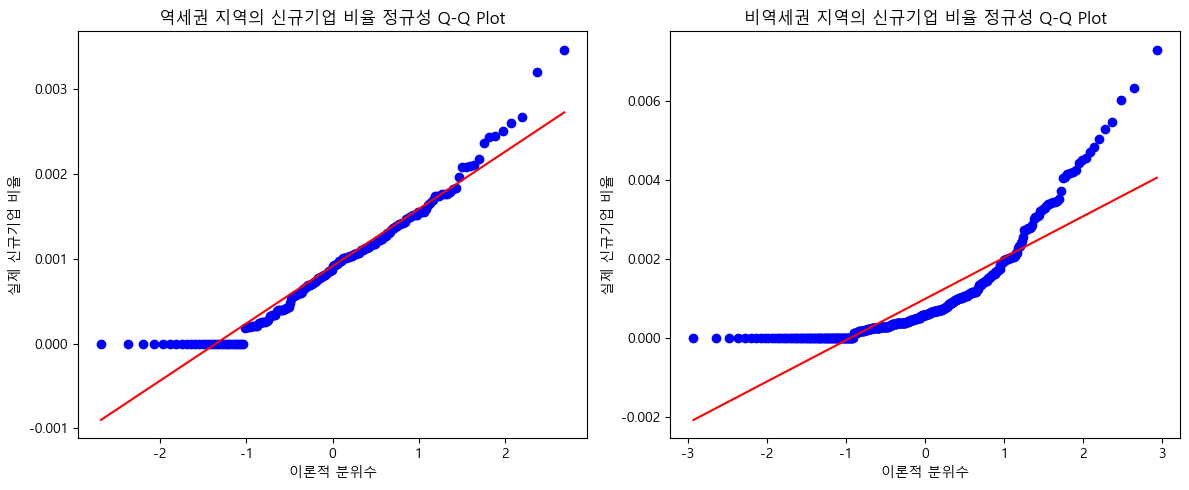

In [377]:
plt.figure(figsize=(12, 5))

# 역세권 Q-Q plot
ax1 = plt.subplot(1, 2, 1)
probplot(station_group, dist="norm", plot=ax1)
ax1.set_title("역세권 지역의 신규기업 비율 정규성 Q-Q Plot")
ax1.set_xlabel("이론적 분위수")
ax1.set_ylabel("실제 신규기업 비율")

# 비역세권 Q-Q plot
ax2 = plt.subplot(1, 2, 2)
probplot(non_station_group, dist="norm", plot=ax2)
ax2.set_title("비역세권 지역의 신규기업 비율 정규성 Q-Q Plot")
ax2.set_xlabel("이론적 분위수")
ax2.set_ylabel("실제 신규기업 비율")

plt.tight_layout()
plt.show()

역세권은 그나마 선을 따라가는데 오른쪽 다와서 선을 많이 벗어남... 정규성 안뜀... 비역세권은 더 뚜렷하게 정규성을 안뜀...
그러므로 맨 휘트니 유 검정 실시

In [378]:
u_stat, mw_p = mannwhitneyu(
    station_group,
    non_station_group,
    alternative="two-sided"
)

h19_result_df = pd.DataFrame([{
    "가설": "H19 역세권 행정동과 비역세권 행정동의 신규기업 비율에는 차이가 있을 것이다",
    "검정방법": "Mann-Whitney U test",
    "그룹변수": "is_station_area",
    "Y변수": "new_corp_ratio",
    "역세권_n": len(station_group),
    "비역세권_n": len(non_station_group),
    "역세권_평균": station_group.mean(),
    "비역세권_평균": non_station_group.mean(),
    "역세권_중앙값": station_group.median(),
    "비역세권_중앙값": non_station_group.median(),
    "역세권_표준편차": station_group.std(),
    "비역세권_표준편차": non_station_group.std(),
    "MannWhitney_U": u_stat,
    "MannWhitney_p": mw_p,
    "판정": "유의함" if mw_p < 0.05 else "유의하지 않음"
}])

display(h19_result_df)

,가설,검정방법,그룹변수,Y변수,역세권_n,비역세권_n,역세권_평균,비역세권_평균,역세권_중앙값,비역세권_중앙값,역세권_표준편차,비역세권_표준편차,MannWhitney_U,MannWhitney_p,판정
0,H19 역세권 행정동과 비역세권 행정동의 신규기업 비율에는 차이가 있을 것이다,Mann-Whitney U test,is_station_area,new_corp_ratio,192,408,0.00091,0.000993,0.00089,0.000592,0.000686,0.001185,43034.0,0.050406,유의하지 않음


- 역세권과 비역세권의 신규기업 비율 차이를 Mann-Whitney U test로 검정한 결과, p-value는 0.0504로 나타났다.
- 이는 유의수준 0.05보다 근소하게 크기 때문에, 역세권과 비역세권 간 신규기업 비율에 통계적으로 유의한 차이가 있다고 보기 어렵다.
- 따라서 “역세권 행정동과 비역세권 행정동의 신규기업 비율에는 차이가 있을 것이다”라는 H19 가설은 5% 유의수준에서는 지지되지 않는다.

다만 p-value가 0.05에 매우 근접하고, 중앙값 기준으로는 역세권 집단의 신규기업 비율이 더 높게 나타나 역세권 여부에 따른 신규기업 진입 차이 가능성은 추가적으로 검토할 필요가 있다.

아 이거는 행정동별 분기로 나눠져있어서 똑같은 행정동이 여러번 등장하므로 값이 저렇게 나온거 같아 행정동으로만 분류해서 평균 테이블 만든 후 다시 검정

In [379]:
h19_dong_data = (
    h19_data
    .groupby(["gu", "adm_dong_nm", "is_station_area", "역세권여부"], as_index=False)
    .agg(
        new_corp_ratio_mean=("new_corp_ratio", "mean"),
        new_corp_cnt_mean=("new_corp_cnt", "mean"),
        store_mer_cnt_mean=("store_mer_cnt", "mean")
    )
)

display(h19_dong_data.head())
display(h19_dong_data.shape)
display(h19_dong_data["역세권여부"].value_counts())

,gu,adm_dong_nm,is_station_area,역세권여부,new_corp_ratio_mean,new_corp_cnt_mean,store_mer_cnt_mean
0,분당구,구미1동,1,역세권,0.001427,9.166667,6430.750000
1,분당구,구미동,0,비역세권,0.000943,8.000000,8449.666667
2,분당구,금곡동,1,역세권,0.000887,8.666667,9801.666667
3,분당구,백현동,1,역세권,0.001257,16.666667,13487.583333
4,분당구,분당동,0,비역세권,0.000531,1.416667,2682.916667


(50, 7)

역세권여부
비역세권    34
역세권     16
Name: count, dtype: int64

In [380]:
station_dong_group = h19_dong_data[
    h19_dong_data["is_station_area"] == 1
]["new_corp_ratio_mean"]

non_station_dong_group = h19_dong_data[
    h19_dong_data["is_station_area"] == 0
]["new_corp_ratio_mean"]

u_stat, p_value = mannwhitneyu(
    station_dong_group,
    non_station_dong_group,
    alternative="two-sided"
)

h19_dong_result_df = pd.DataFrame([{
    "가설": "H19 역세권 행정동과 비역세권 행정동의 신규기업 비율 평균에는 차이가 있을 것이다",
    "분석단위": "행정동별 평균",
    "검정방법": "Mann-Whitney U test",
    "역세권_n": len(station_dong_group),
    "비역세권_n": len(non_station_dong_group),
    "역세권_평균": station_dong_group.mean(),
    "비역세권_평균": non_station_dong_group.mean(),
    "역세권_중앙값": station_dong_group.median(),
    "비역세권_중앙값": non_station_dong_group.median(),
    "MannWhitney_U": u_stat,
    "MannWhitney_p": p_value,
    "판정": "유의함" if p_value < 0.05 else "유의하지 않음"
}])

display(h19_dong_result_df)

,가설,분석단위,검정방법,역세권_n,비역세권_n,역세권_평균,비역세권_평균,역세권_중앙값,비역세권_중앙값,MannWhitney_U,MannWhitney_p,판정
0,H19 역세권 행정동과 비역세권 행정동의 신규기업 비율 평균에는 차이가 있을 것이다,행정동별 평균,Mann-Whitney U test,16,34,0.00091,0.000993,0.001072,0.000581,292.0,0.685076,유의하지 않음


분기별 데이터에서는 역세권과 비역세권의 신규기업 비율 차이가 경계선에 가까웠지만,
행정동별 평균으로 요약해 재검정한 결과 차이는 통계적으로 유의하지 않음.

역세권 여부에 따른 신규기업 비율 차이는 행정동별 평균 기준에서 유의하지 않음.
따라서 H19는 지지되지 않음.

# 20. 가설: 신규기업수 또는 신규기업 비율이 높은 행정동일수록 매출액이 높을 것이다.

20-1) 가설설정
- 귀무가설: 신규기업 수와 매출액 사이에는 유의한 상관관계가 없다.
- 대립가설: 신규기업 수와 매출액 사이에는 유의한 상관관계가 있다.

20-2) 가설설정
- 귀무가설: 신규기업 비율과 매출액 사이에는 유의한 상관관계가 없다.
- 대립가설: 신규기업 비율과 매출액 사이에는 유의한 상관관계가 있다.

매출액은 로그변환해서 보는 방향으로 극단값의 영향 덜받게

In [381]:
h20_base = h19_base.copy()

# 이미 있으면 그대로 쓰고, 없으면 생성
if "new_corp_ratio" not in h20_base.columns:
    h20_base["new_corp_ratio"] = np.where(
        h20_base["store_mer_cnt"] > 0,
        h20_base["new_corp_cnt"] / h20_base["store_mer_cnt"],
        np.nan
    )

# 매출액 로그변환
h20_base["log_sales_amt"] = np.log1p(h20_base["sales_amt"])

h20_data = h20_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "new_corp_cnt",
        "store_mer_cnt",
        "new_corp_ratio",
        "sales_amt",
        "log_sales_amt"
    ]
].dropna()

display(h20_data.head())
display(h20_data.shape)

,base_quarter,gu,adm_dong_nm,new_corp_cnt,store_mer_cnt,new_corp_ratio,sales_amt,log_sales_amt
0,2023Q1,수정구,신흥1동,2.0,4741.0,0.000422,2.533850e+10,23.955591
1,2023Q2,수정구,신흥1동,0.0,4852.0,0.000000,2.648371e+10,23.999796
2,2023Q3,수정구,신흥1동,0.0,4751.0,0.000000,2.583415e+10,23.974963
3,2023Q4,수정구,신흥1동,0.0,4725.0,0.000000,2.626346e+10,23.991444
4,2024Q1,수정구,신흥1동,0.0,4756.0,0.000000,2.431509e+10,23.914363


(600, 8)

In [382]:
h20_results = [
    corr_test(
        h20_data,
        x_col="new_corp_cnt",
        y_col="log_sales_amt",
        hypothesis="H20-1 신규기업 수가 많은 행정동일수록 매출액이 높을 것이다",
        alternative="greater"
    ),
    corr_test(
        h20_data,
        x_col="new_corp_ratio",
        y_col="log_sales_amt",
        hypothesis="H20-2 신규기업 비율이 높은 행정동일수록 매출액이 높을 것이다",
        alternative="greater"
    )
]

h20_result_df = pd.DataFrame(h20_results)
display(h20_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H20-1 신규기업 수가 많은 행정동일수록 매출액이 높을 것이다,new_corp_cnt,log_sales_amt,600,0.6227,0.0,0.6687,0.0,유의함
1,H20-2 신규기업 비율이 높은 행정동일수록 매출액이 높을 것이다,new_corp_ratio,log_sales_amt,600,0.1971,0.0,0.3894,0.0,유의함


신규기업 수가 많은 행정동일수록 매출액이 높은 경향이 0.62로 계수가 뚜렷함 강한 상관관계로 보임
그러나 신규이업 비율로는 매출액과 봤을때 상관관계이긴한데 약한 상관관계로 나타남
- 결론: 전체 점포 수 대비 신규기업 비율이 높은 행정동일수록 로그 매출액도 높아지는 경향이 확인되었다.

신규기업과 매출액 간의 관계를 확인하기 위해 매출액을 로그변환한 log_sales_amt를 사용하여 상관분석을 수행하였다. 분석 결과, 신규기업 수와 로그 매출액 간의 Pearson 상관계수는 0.6227, Spearman 상관계수는 0.6687로 나타났으며, 두 검정 모두 통계적으로 유의하였다. 이는 신규기업 수가 많은 행정동일수록 매출 규모도 높은 경향이 강하게 나타남을 의미한다.
또한 신규기업 비율과 로그 매출액 간에도 Pearson 상관계수 0.1971, Spearman 상관계수 0.3894로 유의한 양의 상관관계가 확인되었다. 따라서 상권 규모를 고려한 신규기업 비율 기준에서도 신규기업 진입 정도가 높은 지역일수록 매출액이 높은 경향이 나타났다.
따라서 H20 가설은 지지된다.

# 21. 가설: 프랜차이즈 수 및 프랜차이즈 침투율이 높을수록 매출액이 높을 것이다.

21-1) 가설설정
- 귀무가설: 프랜차이즈 수가 많은 행정동일수록 유의한 상관관계가 없다.
- 대립가설: 프랜차이즈 수가 많은 행정동일수록 유의한 상관관계가 있다.

21-2) 가설설정
- 귀무가설: 프랜차이즈 침투율과 매출액 사이에는 유의한 상관관계가 없다.
- 대립가설: 프랜차이즈 침투율과 매출액 사이에는 유의한 상관관계가 있다.

똑같이 매출액은 로그변환 후 확인

In [383]:
h21_base = h20_base.copy()

# 매출액 로그변환 컬럼이 없으면 생성
if "log_sales_amt" not in h21_base.columns:
    h21_base["log_sales_amt"] = np.log1p(h21_base["sales_amt"])

In [384]:
# 분석용 테이블 생성
h21_data = h21_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "franchise_cnt",
        "franchise_ratio",
        "sales_amt",
        "log_sales_amt"
    ]
].dropna()

display(h21_data.head())
display(h21_data.shape)

,base_quarter,gu,adm_dong_nm,franchise_cnt,franchise_ratio,sales_amt,log_sales_amt
0,2023Q1,수정구,신흥1동,232.0,4.893482,2.533850e+10,23.955591
1,2023Q2,수정구,신흥1동,235.0,4.843364,2.648371e+10,23.999796
2,2023Q3,수정구,신흥1동,245.0,5.156809,2.583415e+10,23.974963
3,2023Q4,수정구,신흥1동,244.0,5.164021,2.626346e+10,23.991444
4,2024Q1,수정구,신흥1동,251.0,5.277544,2.431509e+10,23.914363


(600, 7)

In [385]:
h21_results = [
    corr_test(
        h21_data,
        x_col="franchise_cnt",
        y_col="log_sales_amt",
        hypothesis="H21-1 프랜차이즈 수가 많은 행정동일수록 매출액이 높을 것이다",
        alternative="greater"
    ),
    corr_test(
        h21_data,
        x_col="franchise_ratio",
        y_col="log_sales_amt",
        hypothesis="H21-2 프랜차이즈 침투율이 높은 행정동일수록 매출액이 높을 것이다",
        alternative="greater"
    )
]

h21_result_df = pd.DataFrame(h21_results)
display(h21_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H21-1 프랜차이즈 수가 많은 행정동일수록 매출액이 높을 것이다,franchise_cnt,log_sales_amt,600,0.7811,0.0,0.8017,0.0,유의함
1,H21-2 프랜차이즈 침투율이 높은 행정동일수록 매출액이 높을 것이다,franchise_ratio,log_sales_amt,600,0.5619,0.0,0.3364,0.0,유의함


와 둘다 피어슨에서의 상관계수는 강한 상관관계로 나타남...아 근데 침투율이 스피어만의 순위관계에서는 0.33으로 조금 중간정도의 상관관계를 보여주네... 침투율이 높다고 해서 매출순위는 그렇게 높게 나오진 않은 편이라는 느낌이 든다.

프랜차이즈와 매출액 간의 관계를 확인하기 위해 매출액을 로그변환한 log_sales_amt를 사용하여 상관분석을 수행하였다.

분석 결과, 프랜차이즈 수와 로그 매출액 간의 Pearson 상관계수는 0.7811, Spearman 상관계수는 0.8017로 나타났으며, 두 검정 모두 통계적으로 유의하였다. 이는 프랜차이즈 수가 많은 행정동일수록 매출액도 높은 강한 양의 관계가 있음을 의미한다.

프랜차이즈 침투율과 로그 매출액 간에도 Pearson 상관계수 0.5619, Spearman 상관계수 0.3364로 유의한 양의 상관관계가 확인되었다. 다만 프랜차이즈 수와 매출액 간의 관계가 더 강하게 나타나, 매출 규모는 프랜차이즈 침투율보다 프랜차이즈 점포 수와 더 밀접하게 관련되는 것으로 해석된다.

따라서 H21 가설은 지지된다.

H21 결과 덕분에 franchise_cnt와 franchise_ratio는 머신러닝 feature 후보로 충분히 가져갈 만하다. 
다만 franchise_cnt는 상권 규모 변수이므로 sales_amt, new_corp_cnt와 중복될 수 있어 나중에 중복성 확인이 필요하다.

# 22. 가설: 프랜차이즈와 개폐업 점포 수는 관련이 있을거다.

22-1) 가설설정
- 귀무가설: 프랜차이즈 수가 많은 행정동일수록 개업 점포수 사이에는 유의한 상관관계가 없을 것이다.
- 대립가설: 프랜차이즈 수가 많은 행정동일수록 개업 점포 수 사이에는 유의한 상관관계가 있을 것이다.

22-2) 가설설정
- 귀무가설: 프랜차이즈 수가 많은 행정동일수록 폐업 점포수 사이에는 유의한 상관관계가 없을 것이다.
- 대립가설: 프랜차이즈 수가 많은 행정동일수록 폐업 점포수 사이에는 유의한 상관관계가 있을 것이다.

In [386]:
# 분석용 테이블 생성
h22_data = h19_base[
    [
        "base_quarter",
        "gu",
        "adm_dong_nm",
        "franchise_cnt",
        "open_cnt",
        "close_cnt"
    ]
].dropna()

display(h22_data.head())
display(h22_data.shape)

,base_quarter,gu,adm_dong_nm,franchise_cnt,open_cnt,close_cnt
0,2023Q1,수정구,신흥1동,232.0,80.0,77.0
1,2023Q2,수정구,신흥1동,235.0,48.0,53.0
2,2023Q3,수정구,신흥1동,245.0,72.0,112.0
3,2023Q4,수정구,신흥1동,244.0,42.0,57.0
4,2024Q1,수정구,신흥1동,251.0,57.0,61.0


(600, 6)

In [387]:
# 개폐업 값 확인
display(
    h22_data[
        ["franchise_cnt", "open_cnt", "close_cnt"]
    ].describe()
)

,franchise_cnt,open_cnt,close_cnt
count,600.000000,600.000000,600.000000
mean,446.660000,82.675000,66.406667
std,551.117497,78.358276,55.672948
min,35.000000,0.000000,1.000000
25%,148.000000,34.000000,30.000000
50%,250.000000,55.000000,50.000000
75%,436.000000,101.250000,83.250000
max,3063.000000,456.000000,322.000000


큰값이 좀 있으므로 피어슨 영향이 있을 거 같음

In [388]:
h22_results = [
    corr_test(
        h22_data,
        x_col="franchise_cnt",
        y_col="open_cnt",
        hypothesis="H22-1 프랜차이즈 수가 많은 행정동일수록 개업 점포 수가 많을 것이다",
        alternative="greater"
    ),
    corr_test(
        h22_data,
        x_col="franchise_cnt",
        y_col="close_cnt",
        hypothesis="H22-2 프랜차이즈 수가 많은 행정동일수록 폐업 점포 수가 많을 것이다",
        alternative="greater"
    )
]

h22_result_df = pd.DataFrame(h22_results)
display(h22_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H22-1 프랜차이즈 수가 많은 행정동일수록 개업 점포 수가 많을 것이다,franchise_cnt,open_cnt,600,0.8223,0.0,0.8987,0.0,유의함
1,H22-2 프랜차이즈 수가 많은 행정동일수록 폐업 점포 수가 많을 것이다,franchise_cnt,close_cnt,600,0.6980,0.0,0.8487,0.0,유의함


둘다 상관관계가 매우 높게 나와 통계적으로 일관되게 움직인다..

프랜차이즈 수와 개업·폐업 점포 수 간의 관계를 분석한 결과, 프랜차이즈 수와 개업 점포 수 간의 Pearson 상관계수는 0.8223, Spearman 상관계수는 0.8987로 나타났다. 또한 프랜차이즈 수와 폐업 점포 수 간의 Pearson 상관계수는 0.6980, Spearman 상관계수는 0.8487로 나타났으며, 두 관계 모두 통계적으로 유의하였다.

이는 프랜차이즈 수가 많은 행정동일수록 개업 점포 수와 폐업 점포 수가 함께 많게 나타나는 경향을 의미한다. 특히 Spearman 상관계수가 높게 나타나, 프랜차이즈 수가 많은 지역일수록 개업 및 폐업 점포 수의 순위도 높게 나타나는 일관된 경향이 확인되었다.

H22는 강한 양의 상관관계가 확인되었고, 프랜차이즈 수는 상권 규모와 점포 진입·퇴출 활발성을 설명하는 핵심 후보 변수로 볼 수 있다